In [1]:
try:
    print_spark_info()
except:
    %run ../spark-instance.ipynb

SparkConf created
Started SparkSession
Spark version 3.5.3
You should be able to access the Spark UI at: https://dacs-compute-gate.ewi.utwente.nl:9999/user/g.luvizottocesar@utwente.nl/proxy/4040/stages/
Note that you may have to Enable extensions first via the Extension Manager.


In [47]:
clean_spark()

CLEANING SPARK INSTANCE...


In [3]:
from datetime import datetime
import math

# installed pkg imports
import numpy as np
import pandas as pd

# pyspark related imports
import pyspark.sql.types as pst
from pyspark.sql import functions as psf
from pyspark.sql.window import Window
from functools import reduce

from lzr_port_handshake import lzr_port_hs_map, EPHEMERAL_START, IANA_HS, EPHEMERAL_HS

import matplotlib.pyplot as plt

## ZMAP TCP

### IPv4 AU

In [8]:
zmap_ts = datetime(2025, 12, 13)  # 13 and 14

ZMAP_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset=tcp-anycast/vp=au-syd"
zmap_df = spark.read.option("basePath", ZMAP_BASE_PATH).option("header", "true").csv(ZMAP_BASE_PATH)

zmap_df.show()

+---------------+----+----+-----+---+
|          saddr|port|year|month|day|
+---------------+----+----+-----+---+
|  104.16.241.82|5060|2025|   12| 14|
|  216.163.179.2|5060|2025|   12| 14|
|  76.223.22.165|5060|2025|   12| 14|
| 166.62.106.139|5060|2025|   12| 14|
|  128.14.69.223|5060|2025|   12| 14|
|  23.174.56.189|5060|2025|   12| 14|
| 104.16.139.145|5060|2025|   12| 14|
|  99.77.190.162|5060|2025|   12| 14|
|  35.241.53.224|5060|2025|   12| 14|
| 35.227.206.203|5060|2025|   12| 14|
|  34.117.197.38|5060|2025|   12| 14|
|  204.70.127.91|5060|2025|   12| 14|
|  35.71.228.139|5060|2025|   12| 14|
|   34.120.0.223|5060|2025|   12| 14|
| 34.117.193.191|5060|2025|   12| 14|
|  34.160.182.12|5060|2025|   12| 14|
|162.159.152.217|5060|2025|   12| 14|
| 212.227.222.46|5060|2025|   12| 14|
|  104.20.51.144|5060|2025|   12| 14|
| 164.132.114.34|5060|2025|   12| 14|
+---------------+----+----+-----+---+
only showing top 20 rows



In [9]:
zmap_df.groupBy("port").count().sort("count", ascending=False).show()

+-----+-------+
| port|  count|
+-----+-------+
| 5060|3478154|
| 2000|3436280|
|  443|2434595|
|   80|2381229|
| 8443|1378283|
| 8080|1369456|
|   53| 703513|
| 8888| 637989|
|20005| 635521|
| 9000| 635411|
| 9099| 635082|
| 8081| 634387|
|  444| 634065|
| 4005| 633466|
| 4006| 632762|
| 8899| 632726|
| 3000| 632542|
| 9090| 632474|
| 3001| 631881|
| 8083| 631699|
+-----+-------+
only showing top 20 rows



### IPv4 NL

In [59]:
zmap_ts = datetime(2025, 12, 2)  # 2 and 3
vp = "nl-ens"

ZMAP_BASE_PATH = f"s3a://catrin/measurements/tool=zmap/dataset=tcp-anycast/vp={vp}"
zmap_df = spark.read.option("basePath", ZMAP_BASE_PATH).option("header", "true").csv(ZMAP_BASE_PATH).filter(psf.col("month") >= zmap_ts.month)

zmap_df.show()

+---------------+----+----+-----+---+
|          saddr|port|year|month|day|
+---------------+----+----+-----+---+
|   104.24.15.41| 443|2025|   12|  2|
| 104.24.136.253| 443|2025|   12|  2|
|  76.223.98.103| 443|2025|   12|  2|
|162.159.205.238| 443|2025|   12|  2|
|  154.197.65.63| 443|2025|   12|  2|
|  104.19.14.124| 443|2025|   12|  2|
|   104.19.60.96| 443|2025|   12|  2|
|     3.33.159.7| 443|2025|   12|  2|
|  104.27.19.111| 443|2025|   12|  2|
| 199.232.250.81| 443|2025|   12|  2|
| 13.227.180.227| 443|2025|   12|  2|
|  76.223.103.93| 443|2025|   12|  2|
|  76.223.98.230| 443|2025|   12|  2|
| 104.17.240.120| 443|2025|   12|  2|
|  104.25.66.147| 443|2025|   12|  2|
|149.248.210.131| 443|2025|   12|  2|
| 199.232.187.99| 443|2025|   12|  2|
|  78.128.122.44| 443|2025|   12|  2|
|   104.19.39.93| 443|2025|   12|  2|
| 13.248.187.150| 443|2025|   12|  2|
+---------------+----+----+-----+---+
only showing top 20 rows



In [6]:
zmap_df.groupBy("port").count().sort("count", ascending=False).show()

+-----+-------+
| port|  count|
+-----+-------+
|  443|2438634|
|   80|2412035|
| 8443|1358895|
| 8080|1354552|
|   53| 697252|
|  444| 671253|
|  465| 666179|
| 2492| 663122|
|57797| 663025|
| 2500| 663018|
|  445| 661879|
| 6646| 660927|
| 8651| 660763|
| 8652| 660208|
| 8701| 660175|
|  458| 660153|
| 4550| 660099|
|  464| 659674|
| 4567| 659586|
| 2557| 659586|
+-----+-------+
only showing top 20 rows



In [60]:
zmap_df.filter(psf.col("port") == 49152).distinct().count()

594439

## ZMap UDP

### IPv4 NL

In [12]:
zmap_udp_nl_ts = datetime(2025, 12, 9)

ZMAP_UDP_NL_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset=udp-anycast/vp=nl-ens"
zmap_udp_nl_df = spark.read.option("basePath", ZMAP_UDP_NL_BASE_PATH).option("header", "true").csv(ZMAP_UDP_NL_BASE_PATH)

zmap_udp_nl_df.filter(
    psf.col("month") >= zmap_udp_nl_ts.month
).show()

+---------------+----+----+-----+---+
|          saddr|port|year|month|day|
+---------------+----+----+-----+---+
|199.232.215.101| 443|2025|   12|  9|
|   104.19.39.93| 443|2025|   12|  9|
|103.160.204.237| 443|2025|   12|  9|
| 199.232.187.99| 443|2025|   12|  9|
|  104.17.39.163| 443|2025|   12|  9|
| 104.25.250.110| 443|2025|   12|  9|
| 13.227.213.227| 443|2025|   12|  9|
|  104.24.154.86| 443|2025|   12|  9|
| 104.16.123.174| 443|2025|   12|  9|
|   34.149.176.7| 443|2025|   12|  9|
| 104.24.157.143| 443|2025|   12|  9|
| 104.21.216.146| 443|2025|   12|  9|
| 34.160.157.232| 443|2025|   12|  9|
| 34.126.237.169| 443|2025|   12|  9|
|  104.27.19.111| 443|2025|   12|  9|
|  104.16.241.82| 443|2025|   12|  9|
|   104.24.15.41| 443|2025|   12|  9|
|  172.64.229.79| 443|2025|   12|  9|
| 104.17.200.143| 443|2025|   12|  9|
| 104.18.118.114| 443|2025|   12|  9|
+---------------+----+----+-----+---+
only showing top 20 rows



In [13]:
zmap_udp_nl_df.filter(
    psf.col("month") >= zmap_udp_nl_ts.month
).groupBy("port").count().sort("count", ascending=False).show()

+----+-------+
|port|  count|
+----+-------+
| 443|1055004|
| 853|   1326|
+----+-------+



In [8]:
zmap_udp_nl_ts = datetime(2026, 1, 30)

ports = [53, 123]
dfs = []
#for port in ports:
ZMAP_UDP_NL_BASE_PATH = f"s3a://catrin/measurements/tool=zmap/dataset=udp-anycast/vp=nl-ens/port=*/year={zmap_udp_nl_ts.year}/month={zmap_udp_nl_ts.month:02d}/day={zmap_udp_nl_ts.day:02d}"
#dfs.append(spark.read.option("basePath", ZMAP_UDP_NL_BASE_PATH).json(ZMAP_UDP_NL_BASE_PATH))
zmap_udp_nl_df = spark.read.json(ZMAP_UDP_NL_BASE_PATH)


#zmap_udp_nl_df = dfs[0].unionByName(dfs[1])

zmap_udp_nl_df.printSchema()

Py4JJavaError: An error occurred while calling o164.json.
: org.apache.spark.SparkException: Job 0 cancelled because SparkContext was shut down
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$cleanUpAfterSchedulerStop$1(DAGScheduler.scala:1253)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$cleanUpAfterSchedulerStop$1$adapted(DAGScheduler.scala:1251)
	at scala.collection.mutable.HashSet.foreach(HashSet.scala:79)
	at org.apache.spark.scheduler.DAGScheduler.cleanUpAfterSchedulerStop(DAGScheduler.scala:1251)
	at org.apache.spark.scheduler.DAGSchedulerEventProcessLoop.onStop(DAGScheduler.scala:3087)
	at org.apache.spark.util.EventLoop.stop(EventLoop.scala:84)
	at org.apache.spark.scheduler.DAGScheduler.$anonfun$stop$3(DAGScheduler.scala:2973)
	at org.apache.spark.util.Utils$.tryLogNonFatalError(Utils.scala:1375)
	at org.apache.spark.scheduler.DAGScheduler.stop(DAGScheduler.scala:2973)
	at org.apache.spark.SparkContext.$anonfun$stop$12(SparkContext.scala:2258)
	at org.apache.spar

In [ ]:
zmap_udp_nl_df.groupBy("port").count().show()

In [ ]:
import dns.message
import binascii
import ntplib


def is_ntp(d):
    raw = binascii.unhexlify(d)
    # https://en.wikipedia.org/wiki/Network_Time_Protocol
    # len(raw) is 48 typically...
    pkt = ntplib.NTPPacket()
    try:
        pkt.from_data(raw)
        if (0 <= pkt.version <= 4) and (0 <= pkt.mode <= 7):
            return True
        else:
            return False
    except:
        return False


def is_dns(d):
    raw = binascii.unhexlify(d)
    try:
        dns.message.from_wire(raw)
        return True
    except:
        return False


def get_dns_data(d):
    raw = binascii.unhexlify(d)
    try:
        return str(dns.message.from_wire(raw))
    except:
        return None

### IPv4 AU

In [14]:
zmap_udp_au_ts = datetime(2025, 12, 13)

ZMAP_UDP_AU_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset=udp-anycast/vp=au-syd"
zmap_udp_au_df = spark.read.option("basePath", ZMAP_UDP_AU_BASE_PATH).option("header", "true").csv(ZMAP_UDP_AU_BASE_PATH)

zmap_udp_au_df.show()

+--------------+----+----+-----+---+
|         saddr|port|year|month|day|
+--------------+----+----+-----+---+
|13.227.213.227| 443|2025|   12| 13|
|  34.96.93.117| 443|2025|   12| 13|
|104.19.204.100| 443|2025|   12| 13|
| 172.64.229.79| 443|2025|   12| 13|
| 34.117.226.76| 443|2025|   12| 13|
|   34.98.70.46| 443|2025|   12| 13|
|   34.8.71.185| 443|2025|   12| 13|
|  104.24.15.41| 443|2025|   12| 13|
|  104.19.60.96| 443|2025|   12| 13|
| 34.128.143.80| 443|2025|   12| 13|
|  34.98.87.106| 443|2025|   12| 13|
| 104.25.66.147| 443|2025|   12| 13|
|34.117.218.161| 443|2025|   12| 13|
|  34.149.54.12| 443|2025|   12| 13|
| 34.98.117.144| 443|2025|   12| 13|
| 34.149.21.247| 443|2025|   12| 13|
| 172.64.34.199| 443|2025|   12| 13|
| 104.24.51.214| 443|2025|   12| 13|
|104.18.118.114| 443|2025|   12| 13|
| 34.149.129.91| 443|2025|   12| 13|
+--------------+----+----+-----+---+
only showing top 20 rows



In [15]:
zmap_udp_au_df.groupBy("port").count().sort("count", ascending=False).show()

+----+-------+
|port|  count|
+----+-------+
| 443|1053201|
| 853|   1327|
+----+-------+



## QUIC -- handed over to Johannes

## LZR

### IPv4 NL

In [46]:
# Connection shunning: in LZR, it happens when ZGrab fails the TCP after the ZMap scan. The host blocks the scanner between scan stages.
# LZR
summary = {
    "TotalResponses": 302307,
    "ZeroWindow": 31905,  # hosts that block clients to send more TCP packets. "we find the feature in a Juniper networks patent [66] and used in Juniper’s Secure Service Gateway Proxy [41] to prevent DDoS attacks through network-based SYN cookies." [LZR paper] "By maintaining a zero-sized TCP window with the client, the middlebox prevents the client from sending data it cannot yet forward to the backend server." [LZR paper]
    "ACKed": 177451,  # packets that got acked
    "Data": 111726,  # hosts that delivered data (excluding unknowns)
    "No_SYNACK": 420,  # LZR retransmits a SYN, doesn't receive a SYN ACK or; initial state of LZR and did not receive any response from the server
    "Rst": 91605,  # TCP RST by the server (close connection): "If a host does not acknowledge the data (e.g., never responds or RSTs the connection without an acknowledgement), LZR fingerprints the host as likely not hosting a real service and does not proceed with further connection attempts." [LZR paper]
    "Fin": 1163,  # TCP FIN by the server (close connection); LZR sends a RST and attempt a next handshake if given at runtime (Fig. 12 [LZR paper])
    "Resp_ack": 177249,  # intermediate states; these are hosts that responded to ACK but did not yet deliver data, but they can deliver data (pure TCP ACK). 
    "HyperACKtive": 0,  # Firewall acking on all ports; "speculates that IPs respond on every port due to the accidental use of a wildcard when configuring the firewall or an overload of the firewall’s SYN-cookie cache." [LZR paper] about [https://devcentral.f5.com/s/question/0D51T00006i7iKu/vulnerability-scan-lists-all-ips-and-port-as-open]
}

protocols = {
    "tls": 466,
    "ssh": 1,
    "pop3-redis": 1,
    "amqp": 1,
    "ftp": 1,
    "unknown": 190583,
    "http": 111255,
}

print(sum(protocols.values()))
print(sum(protocols.values()) - protocols["unknown"]) # unknown - no data (can't determine the service)

#print(sum(summary.values()))
print(sum(summary.values()) - summary["TotalResponses"] - summary["Resp_ack"] - summary["Data"])

302308
111725
893826
302544


In [4]:
lzr_v4_nl_ts = datetime(2026, 1, 18)

LZR_V4_NL_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset=tcp-anycast/format=parquet/vp=nl-ens"

lzr_v4_nl_df = spark.read.option("basePath", LZR_V4_NL_BASE_PATH).parquet(LZR_V4_NL_BASE_PATH)

#lzr_v4_nl_df.show()

In [6]:
ports = lzr_v4_nl_df.select("port").distinct().toPandas()["port"].to_list()

In [7]:
lzr_v4_nl_df.filter(
    psf.col("port") == 49152
).groupBy("fingerprint").count().show()

+-----------+-----+
|fingerprint|count|
+-----------+-----+
|        ftp|    1|
|    unknown| 2714|
|       http|    4|
+-----------+-----+



In [8]:
lzr_v4_nl_df.filter(
    psf.col("port") == 49152
).select("saddr").distinct().count()

2719

In [9]:
lzr_v4_nl_df.filter(
    psf.col("port") == 443
).groupBy("fingerprint").count().show()

+-----------+------+
|fingerprint| count|
+-----------+------+
|    unknown| 64848|
|        tls|138875|
|       http|    42|
|        ssh|     2|
|       amqp|     1|
+-----------+------+



In [10]:
lzr_v4_nl_df.filter(
    psf.col("port") == 443
).select("saddr").distinct().count()


203768

In [54]:
lzr_v4_nl_df.filter(
    (psf.col("port") == 80)
    & (psf.col("fingerprint") == "unknown")
).filter(
    psf.col("data").isNotNull()
).select("saddr", "data").show(truncate=False)

+--------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|saddr         |data                                                                                                                                                                                                                                                                                                                                                                                                               

In [27]:
zmap_ts = datetime(2026, 1, 25)
vp = "nl-ens"

ZMAP_BASE_PATH = f"s3a://catrin/measurements/tool=zmap/dataset=tcp-anycast/vp={vp}/"
ZMAP_PATH = os.path.join(ZMAP_BASE_PATH, f"port=*/year={zmap_ts.year}/month={zmap_ts.month:02d}/day={zmap_ts.day:02d}")

zmap_df = spark.read.option("basePath", ZMAP_BASE_PATH).option("header", "true").json(ZMAP_PATH)

In [29]:
zmap_df.groupBy("port").count().show()

+-----+-------+
| port|  count|
+-----+-------+
| 8080|1536526|
| 3306| 825571|
|  995| 801489|
|   81| 797155|
|49155| 767232|
|  102| 777563|
| 3128| 771550|
|  111| 773161|
|  873| 771081|
|  548| 769276|
|  631| 767561|
|  144| 766162|
|    9| 774761|
|   26| 768481|
|   37| 765397|
|  119| 757036|
|  514| 753803|
|  389| 750344|
|  543| 721881|
|   21| 710173|
+-----+-------+
only showing top 20 rows



In [30]:
zmap_gp_pdf = zmap_df.groupBy("port").count().toPandas()

In [179]:
lzr_v4_nl_ts = datetime(2026, 1, 25)

LZR_V4_NL_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset=tcp-anycast/format=parquet/vp=nl-ens"

lzr_v4_nl_df = spark.read.option("basePath", LZR_V4_NL_BASE_PATH).parquet(LZR_V4_NL_BASE_PATH)

lzr_v4_nl_df.printSchema()

root
 |-- ACK: boolean (nullable = true)
 |-- ACKed: boolean (nullable = true)
 |-- Counter: long (nullable = true)
 |-- FIN: boolean (nullable = true)
 |-- HandshakeNum: long (nullable = true)
 |-- PUSH: boolean (nullable = true)
 |-- RST: boolean (nullable = true)
 |-- SYN: boolean (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- data: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- expectedRToLZR: string (nullable = true)
 |-- fingerprint: string (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- port: integer (nullable = true)



In [35]:
lzr_v4_nl_df.filter(
    psf.col("port") == 22
).filter(
    psf.col("fingerprint") == "unknown"
).groupBy("expectedRToLZR").count().show()

+--------------+------+
|expectedRToLZR| count|
+--------------+------+
|          NULL|401607|
|          data|  1652|
|           ack|    48|
+--------------+------+



In [61]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("fingerprint") == "unknown"
).groupBy("RST", "FIN", "PUSH", "ACKed").count().orderBy("count", ascending=False).show()

+-----+-----+-----+-----+------+
|  RST|  FIN| PUSH|ACKed| count|
+-----+-----+-----+-----+------+
|false| true|false| true|401449|
| true|false|false| true| 58783|
| true|false|false|false| 33407|
|false|false|false|false|   163|
|false|false| true| true|     5|
|false| true|false|false|     3|
+-----+-----+-----+-----+------+



In [83]:
lzr_v4_nl_df.filter(
    psf.col("fingerprint") != "unknown"
).groupBy("RST", "FIN", "PUSH", "ACKed", "SYN", "ACK").count().orderBy("count", ascending=False).show()

+-----+-----+-----+-----+-----+-----+------+
|  RST|  FIN| PUSH|ACKed|  SYN|  ACK| count|
+-----+-----+-----+-----+-----+-----+------+
|false|false| true| true|false| true|467438|
|false|false|false| true|false| true| 65696|
|false| true| true| true|false| true| 15959|
|false| true|false| true|false| true|   264|
| true|false|false|false|false|false|     1|
+-----+-----+-----+-----+-----+-----+------+



In [109]:
lzr_v4_nl_df.filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNotNull()
).groupBy("data").count().sort("count", ascending=False).show()

+--------------------+-----+
|                data|count|
+--------------------+-----+
|Exceeded MaxStart...| 1328|
|Not allowed at th...|  192|
|D   �jHost '145....|  178|
|                   |  148|
|F   �jHost '145....|  142|
|-NOAUTH Authentic...|   27|
|F  �jHost '145....|   21|
|OK [CAPABILITY LO...|   17|
|         h �       |   15|
|@RSYNCD: 32.0 sha...|   13|
|BYE "too many err...|   13|
|                 A|   11|
|         @   ...|   10|
|             [@���|    9|
|          500 OOPS: |    8|
|200 poppassd hell...|    8|
|             HELLO\n|    7|
|     @RSYNCD: 31.0\n|    4|
|\r\n * Your addre...|    3|
|   �jUnknown er...|    3|
+--------------------+-----+
only showing top 20 rows



In [94]:
lzr_v4_nl_df.filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNull()
).withColumn(
    "close_connection", (psf.col("RST") | psf.col("FIN"))
).withColumn(
    "zero_window", psf.col("window") == 0
).groupBy("close_connection", "ACKed", "SYN", "ACK", "zero_window").count().orderBy("count", ascending=False).show()

+----------------+-----+-----+-----+-----------+--------+
|close_connection|ACKed|  SYN|  ACK|zero_window|   count|
+----------------+-----+-----+-----+-----------+--------+
|            true| true|false| true|      false|11630780|
|            true|false|false|false|       true| 1535849|
|           false|false| true| true|      false|  617204|
|           false| true| true| true|      false|  206426|
|            true| true|false|false|       true|   75913|
|           false|false| true| true|       true|   13170|
|            true|false|false| true|      false|     311|
|            true| true|false| true|       true|     113|
|            true|false|false|false|      false|       7|
|            true| true|false|false|      false|       1|
+----------------+-----+-----+-----+-----------+--------+



In [4]:
lzr_unknown_nodata_df = lzr_v4_nl_df.filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNull()
).withColumn(
    "tcp_reason",
        psf.when((psf.col("RST") | psf.col("FIN")), "Ended connection"  # host closed the connection, RST/FIN==True
                ).otherwise(
                    psf.when(psf.col("window") == 0, "Zero-windowed"  # RST/FIN==False but window-size is 0 (and no data came!)
                    ).otherwise(
                        psf.when(psf.col("ACKed") == False, "Stopped at SYN-ACK"  # RST/FIN==False, window-size!=0, SYN==ACK==True, but did not get a final ACK
                                ).otherwise("Other reasons")  # RST/FIN==False, window-size!=0, SYN==ACK==True, received an ACK at some point... and no data came!
                    )
        )
)
    
lzr_unknown_nodata_df.groupBy("tcp_reason").count().show()

+------------------+--------+
|        tcp_reason|   count|
+------------------+--------+
|  Ended connection|13242974|
|     Zero-windowed|   13170|
|     Other reasons|  206426|
|Stopped at SYN-ACK|  617204|
+------------------+--------+



In [102]:
lzr_unknown_nodata_df.filter(
    psf.col("tcp_reason") == "Stopped at SYN-ACK"
).groupBy("expectedRtoLZR").count().show()

+--------------+------+
|expectedRtoLZR| count|
+--------------+------+
|           ack|617204|
+--------------+------+



In [103]:
lzr_unknown_nodata_df.filter(
    psf.col("tcp_reason") == "Other reasons"
).groupBy("expectedRtoLZR").count().show()

+--------------+------+
|expectedRtoLZR| count|
+--------------+------+
|           ack|206426|
+--------------+------+



In [98]:
lzr_unknown_nodata_df.filter(
    psf.col("tcp_reason") == "Other reasons"
).groupBy("port").count().sort("count", ascending=False).show()

+-----+-----+
| port|count|
+-----+-----+
|  443|27024|
| 8443|21129|
| 5671| 6166|
| 4899| 3126|
|  389| 2985|
|   79| 2929|
|  548| 2673|
|    9| 2658|
| 1028| 2652|
| 1025| 2638|
|   88| 2540|
|  139| 2533|
| 1900| 2518|
|  995| 2406|
| 5101| 2375|
| 1755| 2368|
|    7| 2349|
|  515| 2343|
|  111| 2267|
|49156| 2243|
+-----+-----+
only showing top 20 rows



In [105]:
lzr_unknown_nodata_df.filter(
    psf.col("tcp_reason") == "Other reasons"
).filter(psf.col("port")==443).groupBy("acknum").count().sort("count",ascending=False).show(truncate=False)

+----------+-----+
|acknum    |count|
+----------+-----+
|1         |12549|
|1705237525|1    |
|520453268 |1    |
|1538959390|1    |
|3988678494|1    |
|3978998582|1    |
|3448566386|1    |
|3023772408|1    |
|1562694044|1    |
|425992096 |1    |
|1352602325|1    |
|4139872185|1    |
|1163752719|1    |
|451134099 |1    |
|2520329086|1    |
|414720300 |1    |
|2209524882|1    |
|3505215099|1    |
|1855249008|1    |
|910558012 |1    |
+----------+-----+
only showing top 20 rows



In [60]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("fingerprint") == "unknown"
).groupBy("HandshakeNum").count().orderBy("HandshakeNum").show()  # .agg(F.avg("HandshakeNum").alias("avg_handshake_num"))  --> gives an average

+------------+------+
|HandshakeNum| count|
+------------+------+
|           0|    26|
|           1|493784|
+------------+------+



In [75]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNull()
).groupBy("window").count().sort("count", ascending=False).show(5)  #.count()  

+------+------+
|window| count|
+------+------+
| 65535|460235|
|     0| 33442|
| 42340|   100|
| 16384|    13|
| 14600|     5|
+------+------+
only showing top 5 rows



In [84]:
lzr_v4_nl_df.filter(
    psf.col("fingerprint") != "unknown"
).filter(
    (psf.col("RST") == True)
    & (psf.col("FIN") == False)
    & (psf.col("PUSH") == False)
    & (psf.col("ACKed") == False)
    & (psf.col("SYN") == False)
    & (psf.col("ACK") == False)
).show(truncate=False)

+-----+-----+-------+-----+------------+-----+----+-----+------------------------------+------+-----------+-------------------------------------------------------------------------------------------------------------------------------------+-----+--------------+-----------+--------------+----------+-----+---+------+----+-----+---+----+
|ACK  |ACKed|Counter|FIN  |HandshakeNum|PUSH |RST |SYN  |Timestamp                     |acknum|daddr      |data                                                                                                                                 |dport|expectedRToLZR|fingerprint|saddr         |seqnum    |sport|ttl|window|year|month|day|port|
+-----+-----+-------+-----+------------+-----+----+-----+------------------------------+------+-----------+-------------------------------------------------------------------------------------------------------------------------------------+-----+--------------+-----------+--------------+----------+-----+---+------+----+--

In [58]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("fingerprint") == "unknown"
).agg(  
    psf.sum(psf.col("RST").cast("int")).alias("RST_count"),  
    psf.sum(psf.col("FIN").cast("int")).alias("FIN_count"),  
    psf.sum(psf.col("PUSH").cast("int")).alias("PUSH_count"),  
    psf.sum(psf.col("ACKed").cast("int")).alias("ACKed_count"),  
    psf.count("*").alias("total_unknown")  
).show()

+---------+---------+----------+-----------+-------------+
|RST_count|FIN_count|PUSH_count|ACKed_count|total_unknown|
+---------+---------+----------+-----------+-------------+
|    92190|   401452|         5|     460237|       493810|
+---------+---------+----------+-----------+-------------+



In [57]:
lzr_v4_nl_df.filter(
    psf.col("port") == 22
).filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNotNull()
).withColumn(
    "fingerprint", psf.when((psf.col("fingerprint") == "unknown") & (psf.col("port") == 22) & ( (psf.lower(psf.col("data")).contains("ssh")) | (psf.lower(psf.col("data")).contains('exceeded maxstartups')) ), "ssh"
                           ).otherwise(psf.col("fingerprint"))
).groupBy("fingerprint").count().show()

+-----------+-----+
|fingerprint|count|
+-----------+-----+
|    unknown|  192|
|        ssh| 1460|
+-----------+-----+



In [27]:
lzr_v4_nl_df.filter(
    psf.col("port") == 22
).filter(
    psf.col("fingerprint") == "unknown"
).filter(
    psf.col("data").isNotNull()
).groupBy("data").count().sort("count", ascending=False).show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|data                                                                                                   

In [73]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("data").contains("Welcome to UsenetExpress (fe09)")
).show(truncate=False)

+----+-----+-------+-----+------------+----+-----+-----+-----------------------------+----------+-----------+---------------------------------------+-----+--------------+-----------+--------------+----------+-----+---+------+----+-----+---+----+
|ACK |ACKed|Counter|FIN  |HandshakeNum|PUSH|RST  |SYN  |Timestamp                    |acknum    |daddr      |data                                   |dport|expectedRToLZR|fingerprint|saddr         |seqnum    |sport|ttl|window|year|month|day|port|
+----+-----+-------+-----+------------+----+-----+-----+-----------------------------+----------+-----------+---------------------------------------+-----+--------------+-----------+--------------+----------+-----+---+------+----+-----+---+----+
|true|true |0      |false|0           |true|false|false|2026-01-25T13:30:21.95707166Z|2455643236|145.90.8.11|200 Welcome to UsenetExpress (fe09)\r\n|54792|data          |unknown    |185.151.13.119|1700242632|23   |50 |32    |2026|1    |25 |23  |
+----+-----+----

In [66]:
lzr_v4_nl_df.filter(
    psf.col("port") == 23
).filter(
    psf.col("fingerprint") != "unknown"
).select("saddr", "fingerprint").show(truncate=False)

+---------------+-----------+
|saddr          |fingerprint|
+---------------+-----------+
|74.211.63.1    |telnet     |
|103.14.173.90  |telnet     |
|49.49.192.41   |telnet     |
|103.14.246.141 |telnet     |
|103.14.174.61  |telnet     |
|49.49.192.152  |telnet     |
|49.49.192.141  |telnet     |
|103.245.217.237|telnet     |
|1.207.245.16   |telnet     |
|103.14.173.69  |telnet     |
|41.216.190.135 |telnet     |
|103.14.173.209 |telnet     |
|49.49.192.155  |telnet     |
|171.7.64.55    |telnet     |
|49.49.192.132  |telnet     |
|49.49.192.210  |telnet     |
|49.49.192.127  |telnet     |
|103.14.173.93  |telnet     |
|1.207.248.197  |telnet     |
|103.14.173.65  |telnet     |
+---------------+-----------+
only showing top 20 rows



In [12]:
lzr_v4_nl_df.groupBy("port", "fingerprint").count().show()

+----+-----------+------+
|port|fingerprint| count|
+----+-----------+------+
| 443|       amqp|     1|
| 443|        ssh|     2|
| 443|    unknown| 64848|
| 443|        tls|138875|
| 443|       http|    42|
|2121|    unknown|475172|
|  25|       smtp|  4848|
| 143|    unknown|464830|
|3306|    unknown|456861|
|  23|     telnet|   124|
| 110|    unknown|487676|
| 110|       pop3|  2014|
|  25|       http|    20|
|  25|    unknown|432458|
| 143|       imap|  2004|
|  20|    unknown|493236|
|3306|      mysql|   869|
|  23|    unknown|493810|
|2121|        ftp|     8|
|5672|    unknown|372853|
+----+-----------+------+
only showing top 20 rows



In [20]:
lzr_v4_nl_df.select("fingerprint").distinct().show(50)

+---------------+
|    fingerprint|
+---------------+
|        unknown|
|            tls|
|           http|
|           amqp|
|            ssh|
|         telnet|
|            ftp|
|           smtp|
|           pop3|
|       smtp-ftp|
|          mssql|
|           pptp|
|           mqtt|
|           rtsp|
|           ipmi|
|            rdp|
|        siemens|
|         modbus|
|          mysql|
|           imap|
|       postgres|
|            vnc|
|          redis|
|memcached_ascii|
|            bgp|
|        mongodb|
|         oracle|
|     pop3-redis|
|           NULL|
+---------------+



In [14]:
lzr_v4_nl_df.filter(psf.col("fingerprint").isNull()).show()

+----+-----+-------+----+------------+----+----+----+---------+------+-----+----+-----+--------------+-----------+-----+------+-----+----+------+----+-----+---+----+
| ACK|ACKed|Counter| FIN|HandshakeNum|PUSH| RST| SYN|Timestamp|acknum|daddr|data|dport|expectedRToLZR|fingerprint|saddr|seqnum|sport| ttl|window|year|month|day|port|
+----+-----+-------+----+------------+----+----+----+---------+------+-----+----+-----+--------------+-----------+-----+------+-----+----+------+----+-----+---+----+
|NULL| NULL|   NULL|NULL|        NULL|NULL|NULL|NULL|     NULL|  NULL| NULL|NULL| NULL|          NULL|       NULL| NULL|  NULL| NULL|NULL|  NULL|2026|    1| 25|5800|
|NULL| NULL|   NULL|NULL|        NULL|NULL|NULL|NULL|     NULL|  NULL| NULL|NULL| NULL|          NULL|       NULL| NULL|  NULL| NULL|NULL|  NULL|2026|    1| 25| 179|
|NULL| NULL|   NULL|NULL|        NULL|NULL|NULL|NULL|     NULL|  NULL| NULL|NULL| NULL|          NULL|       NULL| NULL|  NULL| NULL|NULL|  NULL|2026|    1| 25|3389|
+---

In [253]:
lzr_gp_pdf = lzr_v4_nl_df.withColumn(
    "service", psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNull()), "unknown without data"
                       ).otherwise(psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNotNull()), "unknown with data"
                                           ).otherwise(psf.col("fingerprint"))
    )
).groupBy("port", "service").count().toPandas()

In [5]:
lzr_unknown_nodata_pdf = lzr_unknown_nodata_df.groupBy("port", "tcp_reason").count().toPandas()

lzr_unknown_pdf = lzr_v4_nl_df.filter(
    (psf.col("fingerprint") == "unknown")
    & (psf.col("data").isNotNull())
).groupBy("port").count().toPandas()

In [6]:
lzr_unknown_nodata_pdf.to_csv("lzr_unknown_nodata.csv", index=False)
lzr_unknown_pdf.to_csv("lzr_unknown.csv", index=False)

In [142]:
#lzr_gp_pdf.to_csv("lzr_gp_pdf.csv", index=False)
#zmap_gp_pdf.to_csv("zmap_gp_pdf.csv", index=False)

lzr_unknown_nodata_pdf = pd.read_csv("lzr_unknown_nodata.csv")
lzr_unknown_pdf = pd.read_csv("lzr_unknown.csv")
zmap_gp_pdf = pd.read_csv("zmap_gp_pdf.csv")
lzr_gp_pdf = pd.read_csv("lzr_gp_pdf.csv")

In [244]:
def expected_and_unexpected_service(port, fingerprint):
    if fingerprint == None or (isinstance(fingerprint, float) and math.isnan(fingerprint)):
        return "Unknown"  # very few cases...

    if lzr_port_hs_map.get(port, None) is None:
        hs = EPHEMERAL_HS if port >= EPHEMERAL_START else IANA_HS
        if fingerprint.split("_")[0].split("-")[0] in hs or fingerprint.split("_")[0].split("-")[-1] in hs:
            return "Expected service"
        elif "unknown" in fingerprint:
            return fingerprint
        else:
            return "Unexpected service"

    expected_service = lzr_port_hs_map[port][-1].split("_")[0]
    if isinstance(expected_service, float) or isinstance(fingerprint, float):
        raise ValueError(str(expected_service) + " fp " + str(fingerprint))
    if expected_service in fingerprint:
        return "Expected service"
    elif fingerprint == "tls" and fingerprint in lzr_port_hs_map[port]:
        return "Expected service"
    elif "unknown" in fingerprint:
        return fingerprint
    else:
        return "Unexpected service"
        

def get_labels_on_port(port):
    #port = int(port_str)
    if lzr_port_hs_map.get(port, None) is None:
        if port >= EPHEMERAL_START:
            return str(port) + " (ephemeral)"
        else:
            return str(port) + " (IANA)"
    hs_list = list(dict.fromkeys(hs.split("_")[0] for hs in lzr_port_hs_map[port]))
    label = str(port) + "/" + "/".join(hs_list[1:])  # skipping the 1st one because it's the "wait"
    return label

In [125]:
color_map = {
    "Expected service": "#4CAF50",      # green
    "Unexpected service": "#1E88E5",    # blue
    "ZMap SYN-ACK": "#E53935",          # red
    "unknown with data": "#9E9E9E"                # gray
    "unknown"
}
colors = sorted([color_map[col] for col in plot_pdf.columns])

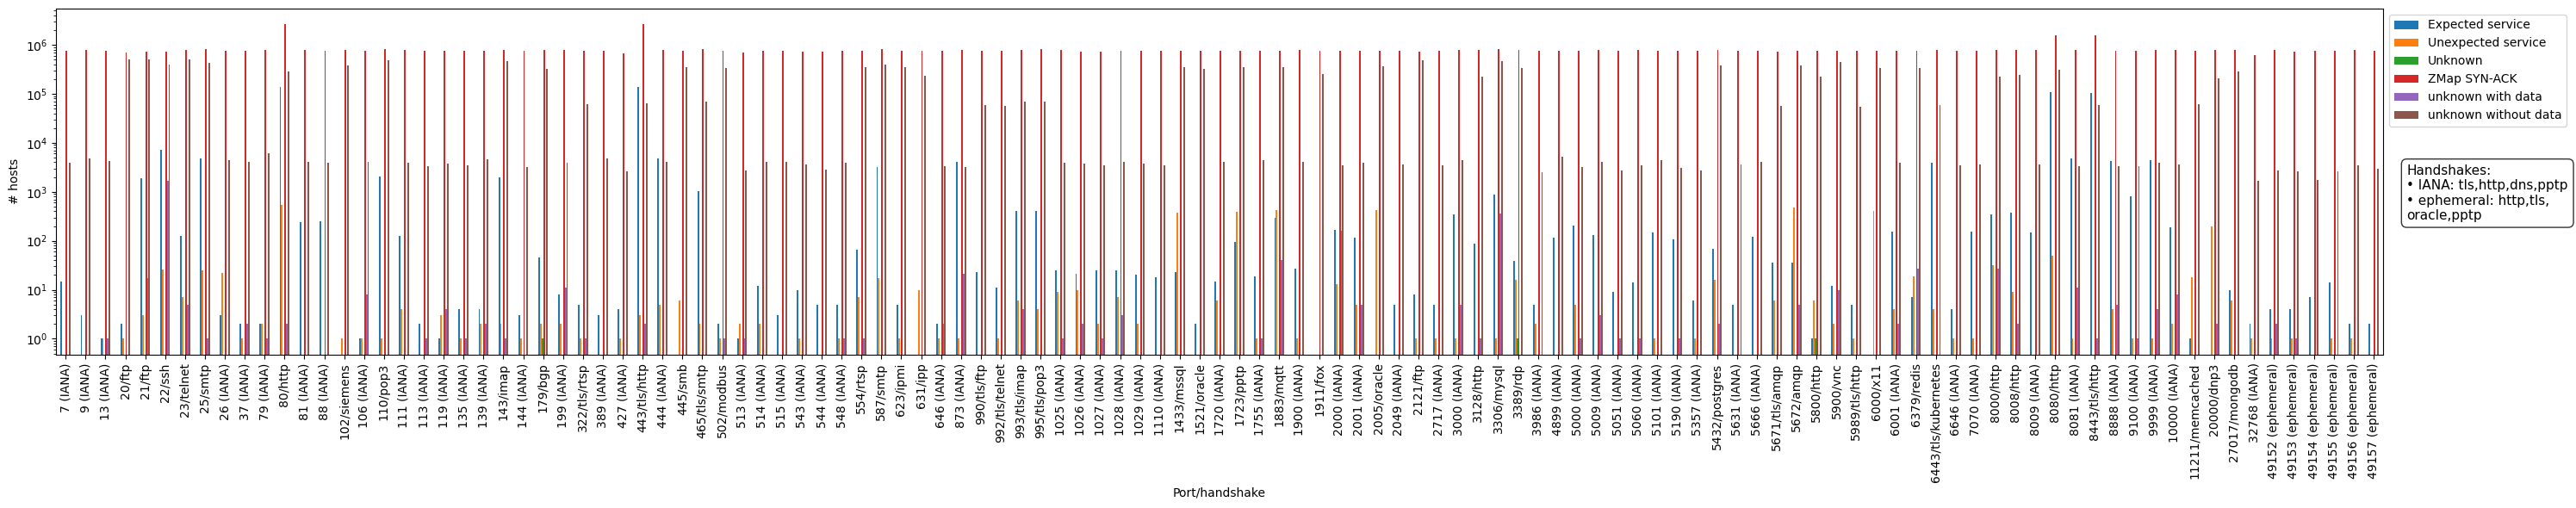

In [255]:
pdf = lzr_gp_pdf.copy()
pdf["service_stat"] = pdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["service"]), axis=1)

if True:
    _zmap_gp_pdf = zmap_gp_pdf.copy()
    _zmap_gp_pdf["service_stat"] = "ZMap SYN-ACK"
    plot_pdf = pd.concat([pdf.drop(columns=["service"]), _zmap_gp_pdf]).groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)

if False:
    plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0).merge(
        zmap_gp_pdf.rename(columns={"count": "ZMap SYN-ACK"}),
        left_index=True,
        right_on="port",
        how="left"
    ).set_index("port")

ax = plot_pdf.plot(
        kind="bar",
        #stacked=True,
        #color=colors,
        figsize=(30, 6)
    )

if False:
    plt.figure(figsize=(500, 6)) #figsize=(7, 6), dpi=480)
    
    x = plot_pdf.index.astype(str)  # ports as labels
    
    cols = plot_pdf.columns
    plt.bar(x, plot_pdf[cols[0]], label=cols[0])
    plt.bar(x, plot_pdf[cols[1]], bottom=plot_pdf[cols[0]], label=cols[1])
    plt.bar(x, plot_pdf[cols[2]], bottom=plot_pdf[cols[1]], label=cols[2])
    plt.bar(x, plot_pdf[cols[3]], bottom=plot_pdf[cols[2]], label=cols[3])


text = (
    "Handshakes:\n"
    "• IANA: tls,http,dns,pptp\n"
    "• ephemeral: http,tls,\noracle,pptp"
)


plt.text(
    1.01, 0.55, text,               # x,y in axes coords
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)

labels = [get_labels_on_port(p) for p in plot_pdf.index]
#ax.set_xticks(range(len(labels)))
if True:
    ax.set_xticklabels(labels, ha="center")
    ax.set_xlabel("Port/handshake")
    ax.set_ylabel("# hosts")
    #ax.set_title("Service categories per port")
    ax.legend(bbox_to_anchor=(1.0, 1), loc="upper left")
    ax.set_yscale("log")
    #ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
    ax.xaxis.grid(False)

if False:
    #plt.yscale("log")  # optional, useful for your scale
    plt.ylabel("Count")
    plt.xlabel("Port")
    plt.xticks(rotation=90)
    plt.legend()
    plt.grid(axis="y", which="both", linestyle="--", linewidth=0.7, alpha=0.6)

plt.tight_layout()
plt.savefig("figures/lzr_overview.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [251]:
plot_pdf[plot_pdf.index == 444]

service_stat,Expected service,Unexpected service,Unknown,ZMap SYN-ACK,unknown
port,,,,,
444,4752,5,0,801237,4060


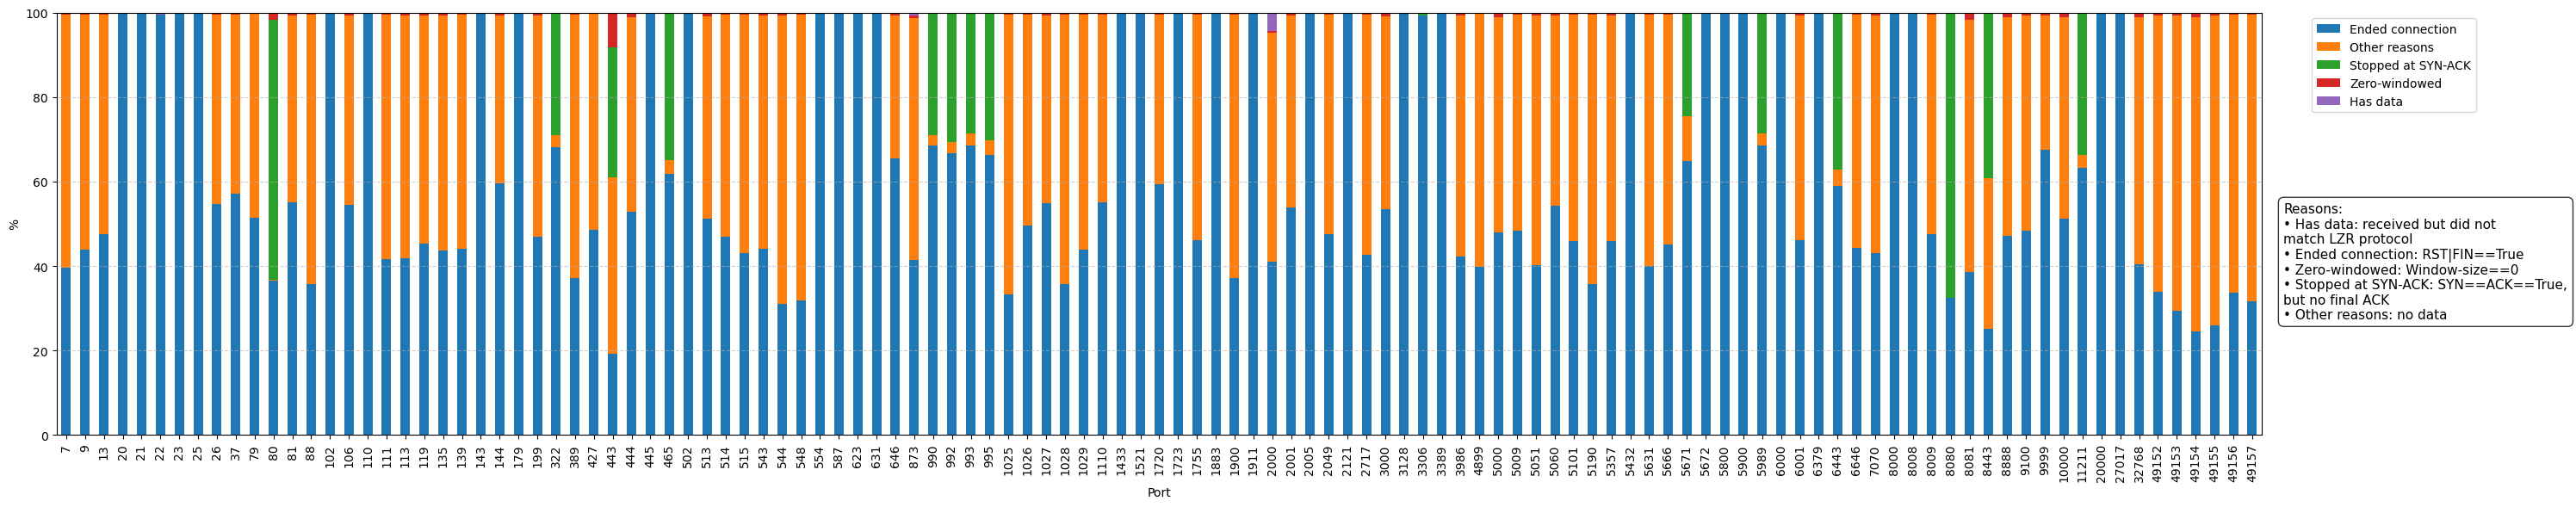

In [24]:
lzr_unknown_nodata_pdf

#df_errors_agg = lzr_unknown_nodata_pdf.groupby("port", as_index=False)["count"].sum().copy()
#df_errors_agg.rename(columns={"count": "errors"}, inplace=True)
errors_pivot = lzr_unknown_nodata_pdf.copy().pivot_table(index="port", columns="tcp_reason", values="count", aggfunc="sum").fillna(0)

df_data = lzr_unknown_pdf.copy().rename(columns={"count": "Has data"}).set_index("port")

df = errors_pivot.join(df_data, how="outer").fillna(0)

df["total"] = df.sum(axis=1)

pct_df = df.div(df["total"], axis=0) * 100
pct_df = pct_df.drop(columns="total")
pct_df = pct_df.sort_index()


ax = pct_df.plot(
    kind="bar",
    stacked=True,
    figsize=(30, 6)
)


text = (
    "Reasons:\n"
    "• Has data: received but did not\nmatch LZR protocol\n"
    "• Ended connection: RST|FIN==True\n"
    "• Zero-windowed: Window-size==0\n"
    "• Stopped at SYN-ACK: SYN==ACK==True,\nbut no final ACK\n"
    "• Other reasons: no data"
)

ax.text(
    1.01, 0.55, text,               # x,y in axes coords
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
)


ax.set_ylabel("%")
ax.set_xlabel("Port")
#ax.set_title("Scan Outcomes per Port")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/lzr_unknown_overview.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [32]:
lzr_v4_nl_df.filter(
    psf.col("data").isNotNull()
).groupBy("port").count().sort("count", ascending=False).show()

+----+------+
|port| count|
+----+------+
|  80|140306|
| 443|138922|
|8080|106157|
|8443|105232|
|  22|  8755|
|  25|  4874|
|8081|  4764|
| 444|  4757|
|9999|  4518|
|8888|  4193|
| 873|  4130|
|6443|  3917|
| 587|  3244|
| 110|  2015|
| 143|  2007|
|  21|  1911|
|3306|  1234|
| 465|  1043|
|9100|   819|
|1883|   754|
+----+------+
only showing top 20 rows



In [180]:
lzr_v4_nl_df.groupBy("saddr").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).show()

+-------------+------------------+-----------------+
|        saddr|             ports|     fingerprints|
+-------------+------------------+-----------------+
|    1.0.0.132|             [443]|            [tls]|
|    1.0.0.219|            [8080]|           [http]|
|      1.0.0.5|            [8080]|           [http]|
|    1.1.1.102|        [80, 8080]|           [http]|
|    1.1.1.109|            [8080]|        [unknown]|
|    1.1.1.112|            [8443]|            [tls]|
|    1.1.1.149|  [8443, 80, 8080]|  [unknown, http]|
|    1.1.1.163|            [8080]|        [unknown]|
|    1.1.1.250|            [8443]|            [tls]|
|     1.1.1.83|       [443, 8080]|   [unknown, tls]|
|   1.12.13.53|              [80]|        [unknown]|
|1.207.245.132|              [22]|            [ssh]|
|  1.228.241.1|             [179]|        [unknown]|
|1.228.251.245|      [1883, 8008]|     [mqtt, http]|
|1.253.100.159|             [554]|           [rtsp]|
|1.253.157.119|            [8000]|        [unk

In [228]:
# export for ip2location
lzr_v4_nl_df.withColumnRenamed("saddr", "ip").groupBy("ip", "year", "month", "day").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).coalesce(1).write.partitionBy("year", "month", "day").parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/testing/")

In [31]:
print("total hosts")
lzr_v4_nl_df.select("saddr").distinct().count()

total hosts


1244427

In [30]:
print("# of hosts without any service attached")
lzr_v4_nl_df.groupBy("saddr").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).filter(
    (psf.size("fingerprints") == 1)
    & (psf.col("fingerprints")[0] == "unknown")
).count()

# of hosts without any service attached


786912

In [231]:
# import from ip2location

ip2loc_lzr_df = spark.read.parquet("s3a://luvizottocesarg-tmp/anycast-service-discovery/lzr/ip2location/output/")
#).withColumns({
#        "ports":  psf.from_json(psf.col("ports"), pst.ArrayType(pst.IntegerType())),
#        "fingerprints": psf.from_json(psf.col("fingerprints"), pst.ArrayType(pst.StringType())),
#        "ip_decimal": psf.col("ip_decimal").cast(pst.DoubleType())
#})

In [232]:
ip2loc_lzr_df.show(truncate=False)

+-------------+----------------+--------------------+-----------+---+-----------------------+------------------------------------------+----------+-----------------+----+-----+---+
|ip           |ports           |fingerprints        |ip_decimal |cc |c_name                 |isp                                       |usage_type|__index_level_0__|year|month|day|
+-------------+----------------+--------------------+-----------+---+-----------------------+------------------------------------------+----------+-----------------+----+-----+---+
|1.0.0.160    |[8443, 80, 8080]|[unknown, http, tls]|1.6777376E7|AU |Australia              |APNIC and CloudFlare DNS Resolver Project |CDN       |0                |2025|1    |25 |
|1.0.0.19     |[80]            |[unknown]           |1.6777235E7|AU |Australia              |APNIC and CloudFlare DNS Resolver Project |CDN       |1                |2025|1    |25 |
|1.0.0.61     |[8443]          |[tls]               |1.6777277E7|AU |Australia              |AP

In [233]:
ip2loc_lzr_df.printSchema()

root
 |-- ip: string (nullable = true)
 |-- ports: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- fingerprints: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- ip_decimal: double (nullable = true)
 |-- cc: string (nullable = true)
 |-- c_name: string (nullable = true)
 |-- isp: string (nullable = true)
 |-- usage_type: string (nullable = true)
 |-- __index_level_0__: long (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



#### LZR attempt with many handshakes...

In [234]:
# ZMAP
# tcp meas
zmaptcp_ts = datetime(2026, 2, 3)

vp = "nl-ens"
ds_tcp = "tcp-anycast"  # ALL handshakes
ds_tcp_test = "tcp-anycast-test"

ZMAP_BASE_PATH = "s3a://catrin/measurements/tool=zmap/dataset={ds}/vp={vp}"
ZMAP_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

In [10]:
lzr_ts = zmaptcp_ts

LZR_BASE_PATH = "s3a://catrin/measurements/tool=lzr/dataset={ds}/format=raw/vp={vp}"
LZR_PATH = "port=*/year={year}/month={month:02d}/day={day:02d}"

In [192]:
zmaptcp_path_f = os.path.join(ZMAP_BASE_PATH.format(ds=ds_tcp, vp=vp), ZMAP_PATH.format(year=zmaptcp_ts.year, month=zmaptcp_ts.month, day=zmaptcp_ts.day))
zmaptcp_df = spark.read.option("basePath", ZMAP_BASE_PATH.format(ds=ds_tcp, vp=vp)).option("header", "true").json(zmaptcp_path_f)
zmaptcp_df.printSchema()

root
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [235]:
zmaptcp_path_f = os.path.join(ZMAP_BASE_PATH.format(ds=ds_tcp_test, vp=vp), ZMAP_PATH.format(year=zmaptcp_ts.year, month=zmaptcp_ts.month, day=zmaptcp_ts.day))
zmaptest_df = spark.read.option("basePath", ZMAP_BASE_PATH.format(ds=ds_tcp_test, vp=vp)).option("header", "true").json(zmaptcp_path_f)
zmaptest_df.printSchema()

root
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [193]:
lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp, vp=vp), LZR_PATH.format(year=lzr_ts.year, month=lzr_ts.month, day=lzr_ts.day))
lzr_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp, vp=vp)).json(lzr_path_f)
lzr_df.printSchema()

root
 |-- ACK: boolean (nullable = true)
 |-- ACKed: boolean (nullable = true)
 |-- Counter: long (nullable = true)
 |-- FIN: boolean (nullable = true)
 |-- HandshakeNum: long (nullable = true)
 |-- PUSH: boolean (nullable = true)
 |-- RST: boolean (nullable = true)
 |-- SYN: boolean (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- data: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- expectedRToLZR: string (nullable = true)
 |-- fingerprint: string (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [236]:
lzr_path_f = os.path.join(LZR_BASE_PATH.format(ds=ds_tcp_test, vp=vp), LZR_PATH.format(year=lzr_ts.year, month=lzr_ts.month, day=lzr_ts.day))
lzrtest_df = spark.read.option("basePath", LZR_BASE_PATH.format(ds=ds_tcp_test, vp=vp)).json(lzr_path_f)
lzrtest_df.printSchema()

root
 |-- ACK: boolean (nullable = true)
 |-- ACKed: boolean (nullable = true)
 |-- Counter: long (nullable = true)
 |-- FIN: boolean (nullable = true)
 |-- HandshakeNum: long (nullable = true)
 |-- PUSH: boolean (nullable = true)
 |-- RST: boolean (nullable = true)
 |-- SYN: boolean (nullable = true)
 |-- Timestamp: string (nullable = true)
 |-- acknum: long (nullable = true)
 |-- daddr: string (nullable = true)
 |-- data: string (nullable = true)
 |-- dport: long (nullable = true)
 |-- expectedRToLZR: string (nullable = true)
 |-- fingerprint: string (nullable = true)
 |-- saddr: string (nullable = true)
 |-- seqnum: long (nullable = true)
 |-- sport: long (nullable = true)
 |-- ttl: long (nullable = true)
 |-- window: long (nullable = true)
 |-- port: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)



In [242]:
# Aggregation on ZMap data
z_pdf = zmaptcp_df.groupBy("port").count().toPandas()


# Aggregation on LZR data
l_pdf = lzr_df.withColumn(
    "service", psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNull()), "unknown without data"
                       ).otherwise(psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNotNull()), "unknown with data"
                                           ).otherwise(psf.col("fingerprint"))
    )
).groupBy("port", "service").count().toPandas()

In [243]:
# Aggregation on ZMap data
ztest_pdf = zmaptest_df.groupBy("port").count().toPandas()


# Aggregation on LZR data
ltest_pdf = lzrtest_df.withColumn(
    "service", psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNull()), "unknown without data"
                       ).otherwise(psf.when((psf.col("fingerprint") == "unknown") & (psf.col("data").isNotNull()), "unknown with data"
                                           ).otherwise(psf.col("fingerprint"))
    )
).groupBy("port", "service").count().toPandas()

In [266]:
pdf = l_pdf.copy()
pdf["service_stat"] = pdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["service"]), axis=1)

if True:
    _z_pdf = z_pdf.copy()
    _z_pdf["service_stat"] = "ZMap SYN-ACK"
    new_plot_pdf = pd.concat([pdf.drop(columns=["service"]), _z_pdf]).groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)

if False:
    ##### another
    new_plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0).merge(
        z_pdf.rename(columns={"count": "ZMap SYN-ACK"}),
        left_index=True,
        right_on="port",
        how="left"
    ).set_index("port")

    ### another
    new_plot_pdf = pdf.groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)

new_plot_pdf["total"] = new_plot_pdf["Expected service"] + new_plot_pdf["Unexpected service"] + new_plot_pdf["unknown with data"] + new_plot_pdf["unknown without data"]
display(new_plot_pdf[["Expected service", "Unexpected service", "unknown with data", "unknown without data", "ZMap SYN-ACK", "total"]])

if False:
    ax = new_plot_pdf.plot(
        kind="bar",
        color=colors,
        #stacked=True,
        logy=True,
    )

    ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.7)
    ax.xaxis.grid(False)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("figures/t.pdf")
    plt.show()

service_stat,Expected service,Unexpected service,unknown with data,unknown without data,ZMap SYN-ACK,total
port,,,,,,
21,3238,113,18,813055,816422,816424
22,7812,102,1290,650022,659220,659226
25,8,0,0,739926,739934,739934
80,314369,748,41,2213988,2529132,2529146
161,0,0,0,704188,704188,704188
443,0,4,0,2551868,2551872,2551872
3389,0,0,0,631080,631080,631080
8883,0,0,0,660591,660591,660591
20000,0,7482,12,708795,716287,716289


In [264]:
total = lzr_df.select("saddr").distinct().count()

no_service = lzr_df.groupBy("saddr").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).filter(
    (psf.size("fingerprints") == 1)
    & (psf.col("fingerprints")[0] == "unknown")
).count()

print("total hosts:", total, "\n# of hosts without any service attached:", no_service, "\n", round(no_service/total*100,1), "%")

total hosts: 2622717 
# of hosts without any service attached: 2293710 
 87.5 %


In [248]:
testpdf = ltest_pdf.copy()
testpdf["service_stat"] = testpdf.apply(lambda row: expected_and_unexpected_service(row["port"], row["service"]), axis=1)

_ztest_pdf = ztest_pdf.copy()
_ztest_pdf["service_stat"] = "ZMap SYN-ACK"
new_plottest_pdf = pd.concat([testpdf.drop(columns=["service"]), _ztest_pdf]).groupby(["port", "service_stat"])["count"].sum().unstack(fill_value=0)

display(new_plottest_pdf[["Expected service", "Unexpected service", "unknown with data", "unknown without data", "ZMap SYN-ACK"]])

service_stat,Expected service,Unexpected service,unknown with data,unknown without data,ZMap SYN-ACK
port,,,,,
21,807,3,10,1561,811518
22,3986,21,720,839,787475
25,2332,29,1,976,798502
80,114898,477,3,10401,2560904
161,3,2,0,4444,775204
443,0,0,0,5154,2556071
3389,31,11,0,849,760830
8883,221,0,0,3644,762869
20000,0,120,3,25,683680


In [263]:
total = lzrtest_df.select("saddr").distinct().count()

no_service = lzrtest_df.groupBy("saddr").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).filter(
    (psf.size("fingerprints") == 1)
    & (psf.col("fingerprints")[0] == "unknown")
).count()

print("total hosts:", total, "\n# of hosts without any service attached:", no_service, "\n", round(no_service/total*100,1), "%")

total hosts: 159635 
# of hosts without any service attached: 34041 
 21.3 %


In [259]:
# old measurements (baseline)
display(plot_pdf[plot_pdf.index.isin([30005, 50805, 49154, 49152, 80, 443, 21, 22, 25, 3389, 20000, 8883, 161])][["Expected service", "Unexpected service", "unknown with data", "unknown without data", "ZMap SYN-ACK"]])

service_stat,Expected service,Unexpected service,unknown with data,unknown without data,ZMap SYN-ACK
port,,,,,
21,1891,3,17,495890,710173
22,7077,26,1652,401655,729332
25,4848,25,1,432457,817244
80,139766,538,2,283796,2593057
443,138917,3,2,64846,2616368
3389,39,16,0,337288,770811
20000,0,200,2,204609,770261
49152,4,1,2,2712,773768
49154,7,0,0,1761,745608


In [265]:
total = lzr_v4_nl_df.select("saddr").distinct().count()

no_service = lzr_v4_nl_df.groupBy("saddr").agg(
    psf.collect_set("port").alias("ports"),
    psf.collect_set("fingerprint").alias("fingerprints")
).filter(
    (psf.size("fingerprints") == 1)
    & (psf.col("fingerprints")[0] == "unknown")
).count()

print("total hosts:", total, "\n# of hosts without any service attached:", no_service, "\n", round(no_service/total*100,1), "%")

total hosts: 1244427 
# of hosts without any service attached: 786912 
 63.2 %


## ZGrab

In [5]:
# how many IPs that we find a service on it
# protocols = []  # build from all protocols we scan
#broadcast_protocols = spark.sparkContext.broadcast(protocols)


# VERY SLOW!
@psf.pandas_udf(psf.StringType())
def get_service_from_zgrab_data(data: pd.Series) -> pd.Series:
    #_protocols = broadcast_protocols.value
    
    def _get_service_from_zgrab_data(x):
        protocol = None
        for k in x.keys():
            if x[k] is None:
                continue
            if x[k].get("status", None):
                protocol = k
                break
        protocol_dict = x[protocol]
    
        if protocol_dict["status"] == "success":
            # it simply succeeded with the handshake 
            if len(x.get("result", {})) == 0 or (protocol_dict["result"] and protocol_dict["result"] != {}):
                # with or without any results...
                return f"{protocol}"
            #else:
                # should not occurr..
            #    return "Unknown"
        else:
            if len(x.get("result", {})) == 0:  # =={}
                return "NoResponse"
            else:
                return "Error"

        # this should not occurr...
        return "Unknown"

    return data.apply(_get_service_from_zgrab_data)

# OLD
def _get_df_service_from_zgrab_data(df):
    # protocol = first key where data[k] is not null and data[k].status is not null
    protocol = psf.expr("""
      element_at(
        filter(
          map_keys(data),
          k -> data[k] is not null AND data[k].status is not null
        ),
        1
      )
    """)
    
    status = psf.expr("data[protocol].status")
    result = psf.expr("data[protocol].result")
    
    service = (
        psf.when(protocol.isNull(), psf.lit("Unknown")  # or whatever you want if nothing matches
        ).when(status == "success", protocol.cast("string")
        ).otherwise(
            psf.when(result.isNull() | (psf.size(result) == 0), psf.lit("NoResponse")
            ).otherwise(psf.lit("Error"))
        )
    )
    
    df2 = (
        df.withColumn("protocol", protocol).withColumn("service", service
                                                      ).drop("protocol")  # optional
    )
    return df2

In [4]:
# operations in spark for optimization; chatgpt help
def get_df_service_from_zgrab_data(df):
    protocols = df.schema["data"].dataType.names

    # first protocol with non-null status in this priority order
    protocol = psf.coalesce(*[
        psf.when(psf.col(f"data.{p}.status").isNotNull(), psf.lit(p)) for p in protocols
    ])

    # so do it with explicit when chain:
    service = psf.coalesce(*[
        psf.when(psf.col(f"data.{p}.status").isNotNull(),
                   psf.when(psf.col(f"data.{p}.status") == "success", psf.lit(p)
                   ).otherwise(
                        #psf.when(psf.col(f"data.{p}.result").isNull(), psf.lit("NoResponse") # takes 16min
                        #).otherwise(psf.lit("Error"))
                        psf.lit("unknown")  # this is faster, <1min  <-- choose this!
                   )
              )
        for p in protocols
    ], psf.lit("unknown"))

    return df.withColumn("service", service)

In [37]:
snapshot = datetime(2026, 2, 20)
snapshot_mail = datetime(2026, 2, 25)  # datetime(2026, 2, 24)
ds = "tcp-anycast"
ds_sni = "tcp-anycast-sni"
zgrab_path = "s3a://catrin/measurements/tool=zgrab/dataset={ds}/format=parquet/vp={vp}/port=all_ports/year={year}/month={month:02d}/day={day:02d}/"
zgrab_raw_path = "s3a://catrin/measurements/tool=zgrab/dataset={ds}/format=raw/vp={vp}/port=email_ports/year={year}/month={month:02d}/day={day:02d}/"

In [38]:
vp = "nl-ens"

zgrab_df = spark.read.parquet(
    zgrab_path.format(ds=ds, vp=vp, year=snapshot.year, month=snapshot.month, day=snapshot.day)
)

zgrab_sni_df = spark.read.parquet(
    zgrab_path.format(ds=ds_sni, vp=vp, year=snapshot.year, month=snapshot.month, day=snapshot.day)
)

zgrab_email_df = spark.read.json(
    zgrab_raw_path.format(ds=ds, vp=vp, year=snapshot_mail.year, month=snapshot_mail.month, day=snapshot_mail.day)
)

In [14]:
# protocols scanned:
protocols = zgrab_df.schema["data"].dataType.names
print(protocols)

['amqps', 'ftps', 'https', 'imaps', 'pop3s', 'smtps', 'smtpss']


In [20]:
zgrab_df.filter(
    psf.col("port") == 443
).groupBy("data.https.status").count(
).withColumn(
    "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
).show()


zgrab_sni_df.filter(
    psf.col("port") == 443
).groupBy("data.https.status").count(
).withColumn(
    "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
).show()

+------------------+------+-------------------+
|            status| count|            percent|
+------------------+------+-------------------+
|           success|476556|  79.73617371575429|
|connection-timeout|  1927|0.32242088390505735|
|        io-timeout|  6183|  1.034524299525153|
|     unknown-error|113000| 18.906881100815507|
+------------------+------+-------------------+

+------------------+------+------------------+
|            status| count|           percent|
+------------------+------+------------------+
|           success|487395| 81.54972844364579|
|connection-timeout|  2022|0.3383160494322916|
|        io-timeout|  6370|1.0658126779840245|
|     unknown-error|101879|17.046142828937903|
+------------------+------+------------------+



In [45]:
zgrab_email_df.filter(
    psf.col("port") == 143
).groupBy("data.smtps.status").count(
).withColumn(
    "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
).show()

+------+-----+-------+
|status|count|percent|
+------+-----+-------+
|  NULL|    2|  100.0|
+------+-----+-------+



In [17]:
for protocol in protocols:
    print(protocol)
    zgrab_df.filter(
        psf.col(f"data.{protocol}.status").isNotNull()
    ).groupBy(f"data.{protocol}.status").count().sort("count", ascending=False
    ).withColumn(
        "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
    ).show()

amqps
+--------------+-----+------------------+
|        status|count|           percent|
+--------------+-----+------------------+
|protocol-error|   40| 43.01075268817204|
|       success|   37|39.784946236559136|
| unknown-error|   16| 17.20430107526882|
+--------------+-----+------------------+

ftps
+-------------+-----+------------------+
|       status|count|           percent|
+-------------+-----+------------------+
|      success|   58| 82.85714285714286|
|   io-timeout|    9|12.857142857142856|
|unknown-error|    3| 4.285714285714286|
+-------------+-----+------------------+

https
+------------------+------+------------------+
|            status| count|           percent|
+------------------+------+------------------+
|           success|490920|  65.4105614633035|
|     unknown-error|248226| 33.07382471643032|
|        io-timeout|  7322|0.9755889575374974|
|connection-timeout|  4053|0.5400248627286911|
+------------------+------+------------------+

imaps
+----------------

In [23]:
for protocol in protocols:
    print(protocol)
    zgrab_sni_df.filter(
        psf.col(f"data.{protocol}.status").isNotNull()
    ).groupBy(f"data.{protocol}.status").count().sort("count", ascending=False
    ).withColumn(
        "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
    ).show()

amqps
+--------------+-----+------------------+
|        status|count|           percent|
+--------------+-----+------------------+
|protocol-error|   40| 43.01075268817204|
|       success|   37|39.784946236559136|
| unknown-error|   15|16.129032258064516|
|    io-timeout|    1|1.0752688172043012|
+--------------+-----+------------------+

ftps
+-------------+-----+------------------+
|       status|count|           percent|
+-------------+-----+------------------+
|      success|   58| 82.85714285714286|
|   io-timeout|    9|12.857142857142856|
|unknown-error|    3| 4.285714285714286|
+-------------+-----+------------------+

https
+------------------+------+------------------+
|            status| count|           percent|
+------------------+------+------------------+
|           success|513162|  68.3741027899286|
|     unknown-error|223742| 29.81155757134044|
|        io-timeout|  9588|1.2775125546120627|
|connection-timeout|  4029|0.5368270841188987|
+------------------+------+--

In [18]:
def get_success_failure_per_protocol(df):
    all_protocol_dfs = []
    
    for protocol in df.schema["data"].dataType.names:
        all_protocol_dfs.append(
            df
            .filter(psf.col(f"data.{protocol}.status").isNotNull())
            .withColumn(
                "result",
                psf.when(psf.col(f"data.{protocol}.status") == "success", "success")
                 .otherwise("failure")
            )
            .groupBy("result")
            .count()
            .withColumn("protocol", psf.lit(protocol))
        )
    
    # union all protocols
    final_df = all_protocol_dfs[0]
    for df in all_protocol_dfs[1:]:
        final_df = final_df.unionByName(df)
    
    return final_df

In [19]:
def get_combined_success_rate_pdf(df, sni_df):
    final_df = get_success_failure_per_protocol(df)
    final_sni_df = get_success_failure_per_protocol(sni_df)
    
    pdf = (
        final_df
        .toPandas()
    )
    
    pivot_pdf = (
        pdf
        .pivot(index="protocol", columns="result", values="count")
        .fillna(0)
    )
    
    sni_pdf = (
        final_sni_df
        .toPandas()
    )
    
    pivot_sni_pdf = (
        sni_pdf
        .pivot(index="protocol", columns="result", values="count")
        .fillna(0)
    )
    
    pivot_pdf.columns = pd.MultiIndex.from_product(
        [["No SNI"], pivot_pdf.columns]
    )
    
    pivot_sni_pdf.columns = pd.MultiIndex.from_product(
        [["SNI"], pivot_sni_pdf.columns]
    )
    
    combined_pdf = pd.concat([pivot_pdf, pivot_sni_pdf], axis=1)
    
    # Ensure same protocol order
    combined_pdf = combined_pdf.sort_index()

    return combined_pdf


def get_success_rate_pdf(df, label):
    final_df = get_success_failure_per_protocol(df)
    
    pdf = (
        final_df
        .toPandas()
    )
    
    pivot_pdf = (
        pdf
        .pivot(index="protocol", columns="result", values="count")
        .fillna(0)
    )
    
    
    pivot_pdf.columns = pd.MultiIndex.from_product(
        [[label], pivot_pdf.columns]
    )
    
    return pivot_pdf

In [39]:
combined_nl_pdf = get_combined_success_rate_pdf(zgrab_df, zgrab_sni_df)

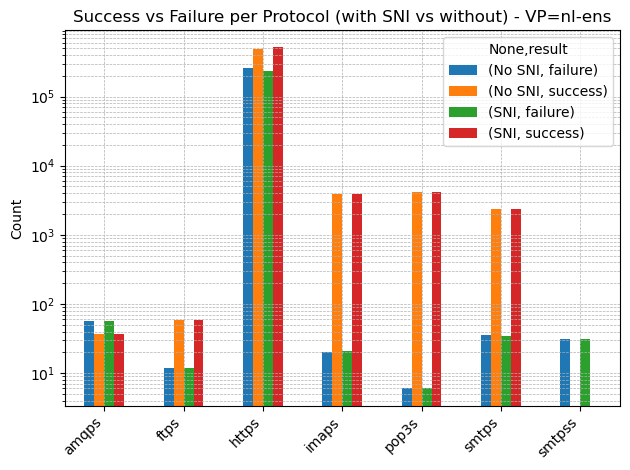

In [52]:
fig, ax = plt.subplots(
    #figsize=(10,6)
)

combined_nl_pdf.plot(
    kind="bar",
    ax=ax
)

ax.set_yscale("log")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_title("Success vs Failure per Protocol (with SNI vs without) - VP=nl-ens")

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
email_pdf = get_success_rate_pdf(zgrab_email_df, "email")

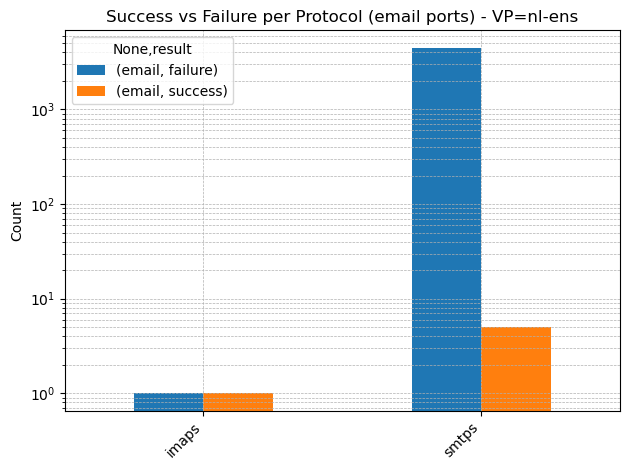

In [41]:
fig, ax = plt.subplots(
    #figsize=(10,6)
)

email_pdf.plot(
    kind="bar",
    ax=ax
)

ax.set_yscale("log")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_title("Success vs Failure per Protocol (email ports) - VP=nl-ens")

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
vp = "au-syd"

zgrab_au_df = spark.read.parquet(
    zgrab_path.format(ds=ds, vp=vp, year=snapshot.year, month=snapshot.month, day=snapshot.day)
)

zgrab_sni_au_df = spark.read.parquet(
    zgrab_path.format(ds=ds_sni, vp=vp, year=snapshot.year, month=snapshot.month, day=snapshot.day)
)

zgrab_email_au_df = spark.read.json(
    zgrab_raw_path.format(ds=ds, vp=vp, year=snapshot_mail.year, month=snapshot_mail.month, day=snapshot_mail.day)
)

In [54]:
combined_au_pdf = get_combined_success_rate_pdf(zgrab_au_df, zgrab_sni_au_df)

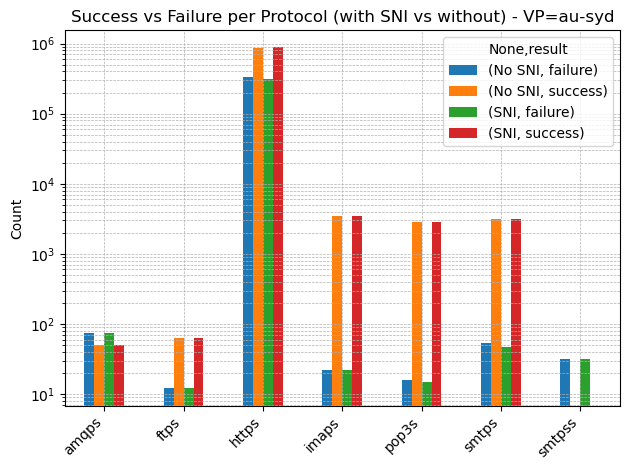

In [58]:
fig, ax = plt.subplots(
    #figsize=(10,6)
)

combined_au_pdf.plot(
    kind="bar",
    ax=ax
)

ax.set_yscale("log")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_title("Success vs Failure per Protocol (with SNI vs without) - VP=au-syd")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [30]:
email_au_pdf = get_success_rate_pdf(zgrab_email_au_df, "email")

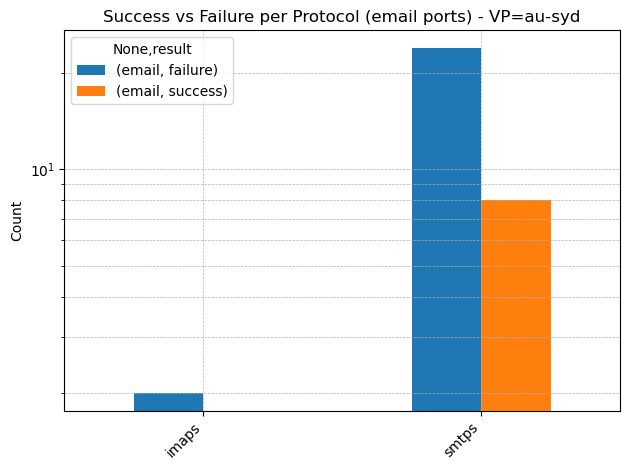

In [31]:
fig, ax = plt.subplots(
    #figsize=(10,6)
)

email_au_pdf.plot(
    kind="bar",
    ax=ax
)

ax.set_yscale("log")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_title("Success vs Failure per Protocol (email ports) - VP=au-syd")

ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

now how many IPs got a service

In [62]:
zgrab_service_df = get_df_service_from_zgrab_data(
    zgrab_df
).select("ip", "port", "service")

success = zgrab_service_df.filter(
    psf.col("service") != "Error"
).select("ip").distinct().count()

if False:
    what = zgrab_service_df.groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
    ).filter(
        ~(
            (psf.size("services") >= 1) &
            (psf.col("services") != psf.array(psf.lit("Error")))
        )
    ).select("ip").distinct().count()

total = zgrab_service_df.select("ip").distinct().count()

print(success/total*100)

77.03746430888594


In [64]:
zgrab_service_df.groupBy("service").count().sort("count", ascending=False).show()

+-------+------+
|service| count|
+-------+------+
|  https|856906|
|  Error|338368|
|  imaps|  3485|
|  smtps|  3164|
|  pop3s|  2806|
|   ftps|    64|
|  amqps|    50|
+-------+------+



### IPv4 NL -- old

#### no HRP

In [4]:
zgrab_v4_nl_ts = datetime(2025, 12, 14)

ZGRAB_V4_NL_BASE_PATH = "s3a://catrin/measurements/tool=zgrab/dataset=tcp-anycast/format=parquet/vp=nl-ens/port=top100"

zgrab_v4_nl_df = spark.read.option("basePath", ZGRAB_V4_NL_BASE_PATH).parquet(ZGRAB_V4_NL_BASE_PATH)

#zgrab_v4_nl_df.show()

In [12]:
# comparing port 80 http without setting a specific timeout.
# without timeout (port 80, nl-ens scans, from 2026-01-15 14:19:13, no HRP):
#  26846 "connection-timeout" 12%
#  45797 "io-timeout" 21%
# 138682 "success"  65%
#     45 "unknown-error" .02%

s=138682
cto=26846
iot=45797
u=45
t=cto+iot+s+u
print(t, s/t*100, cto/t*100, iot/t*100, u/t*100)

zgrab_v4_nl_df.filter(
    psf.col("port") == 80
).groupBy("data.http.status").count(
).withColumn(
    "percent", (psf.col("count") / psf.sum("count").over(Window.partitionBy()) ) * psf.lit(100)
).show()

print(111173+54168+45993+36)

211370 65.61101386194824 12.700950939111511 21.666745517339265 0.021289681600984055
+------------------+------+--------------------+
|            status| count|             percent|
+------------------+------+--------------------+
|           success|111173|    52.5963949472489|
|connection-timeout| 54168|  25.627099399157878|
|        io-timeout| 45993|  21.759473908312437|
|     unknown-error|    36|0.017031745280787245|
+------------------+------+--------------------+

211370


In [5]:
# protocols scanned:
protocols = zgrab_v4_nl_df.schema["data"].dataType.names
print(protocols)

['banner', 'ftp', 'ftps', 'http', 'https', 'imap', 'imaps', 'ipp', 'mysql', 'pop3', 'pop3s', 'postgres', 'pptp', 'smtps', 'ssh', 'telnet']


In [14]:
protocols = zgrab_v4_nl_df.schema["data"].dataType.names

for protocol in protocols:
    print(protocol)
    zgrab_v4_nl_df.filter(
        psf.col(f"data.{protocol}.status").isNotNull()
    ).groupBy(f"data.{protocol}.status").count().show()


banner
+------------------+--------+
|            status|   count|
+------------------+--------+
|           success| 6708557|
|connection-timeout| 3796566|
|        io-timeout|15947688|
+------------------+--------+

ftp
+------------------+------+
|            status| count|
+------------------+------+
|           success|  1706|
|connection-timeout|136872|
|        io-timeout|902374|
+------------------+------+

ftps
+------------------+------+
|            status| count|
+------------------+------+
|           success|     6|
|connection-timeout| 42381|
|        io-timeout| 47677|
|     unknown-error|251724|
+------------------+------+

http
+------------------+-------+
|            status|  count|
+------------------+-------+
|           success| 118337|
|connection-timeout| 253822|
|        io-timeout|1517823|
|     unknown-error|     83|
+------------------+-------+

https
+------------------+------+
|            status| count|
+------------------+------+
|           success|  3

In [25]:
# are there any scan module (e.g., http) that reported also on another module (e.g., it has smtp AND http when scanned only for http)
# the result must be an empty table!
protocols = zgrab_v4_nl_df.schema["data"].dataType.names

n_protocols = sum(
    psf.when(psf.col(f"data.{p}.status").isNotNull(), psf.lit(1)).otherwise(psf.lit(0))
    for p in protocols
)

df2 = zgrab_v4_nl_df.withColumn("n_protocols_present", n_protocols)

df2.filter(psf.col("n_protocols_present") > 1).select("ip", "n_protocols_present", "data").show(truncate=False)

+---+-------------------+----+
|ip |n_protocols_present|data|
+---+-------------------+----+
+---+-------------------+----+



In [196]:
get_df_service_from_zgrab_data(
    zgrab_v4_nl_df
).groupBy("service").count(
).show(truncate=False)

+--------+--------+
|service |count   |
+--------+--------+
|postgres|128     |
|smtps   |312     |
|banner  |6708557 |
|Error   |27369311|
|imaps   |109     |
|http    |118337  |
|ftps    |6       |
|pptp    |275     |
|pop3s   |247     |
|ftp     |1706    |
|mysql   |402     |
|https   |3709    |
|pop3    |1197    |
|ipp     |1       |
|telnet  |84      |
|ssh     |5555    |
|imap    |1244    |
+--------+--------+



In [51]:
try:
    zgrab_v4_nl_service_df.unpersist()
except:
    pass

zgrab_v4_nl_service_df = get_df_service_from_zgrab_data(
    zgrab_v4_nl_df
).select("ip", "port", "service", "year", "month", "day")

zgrab_v4_nl_service_df.persist()

DataFrame[ip: string, port: bigint, service: string, year: int, month: int, day: int]

In [52]:
zgrab_v4_nl_service_df.show()

+--------------+----+-------+----+-----+---+
|            ip|port|service|year|month|day|
+--------------+----+-------+----+-----+---+
|35.227.204.204| 427|  Error|2025|   12| 14|
|130.211.40.186| 427|  Error|2025|   12| 14|
| 34.110.197.41| 427|  Error|2025|   12| 14|
|    34.36.66.7| 427|  Error|2025|   12| 14|
| 34.36.103.136| 427|  Error|2025|   12| 14|
|   34.117.10.8| 427|  Error|2025|   12| 14|
|34.120.173.166| 427|  Error|2025|   12| 14|
|34.149.229.208| 427|  Error|2025|   12| 14|
|43.174.195.130| 427|  Error|2025|   12| 14|
| 34.96.125.199| 427| banner|2025|   12| 14|
| 34.120.223.71| 427| banner|2025|   12| 14|
|34.120.182.149| 427|  Error|2025|   12| 14|
|35.244.211.168| 427| banner|2025|   12| 14|
| 15.197.70.217| 427|  Error|2025|   12| 14|
|  34.49.52.120| 427| banner|2025|   12| 14|
|35.186.199.121| 427|  Error|2025|   12| 14|
| 34.111.41.105| 427|  Error|2025|   12| 14|
| 34.98.100.209| 427|  Error|2025|   12| 14|
| 34.54.230.245| 427|  Error|2025|   12| 14|
|  34.36.2

In [54]:
zgrab_v4_nl_service_df.filter(
    psf.col("service") != "Error"
).select("ip").distinct().count()

398798

In [57]:
zgrab_v4_nl_service_df.groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    ~(
        (psf.size("services") >= 1) &
        (psf.col("services") != psf.array(psf.lit("Error")))
    )
).select("ip").distinct().count()

258744

In [1]:
398798/(258744+398798)*100

60.649814004276536

In [188]:
def get_cdf_pdf_port_error_cnt(df):
    port_cnt_pdf = df.sort("port", ascending=True).toPandas()
    
    port_cnt_pdf["cdf_pct"] = port_cnt_pdf["count"].cumsum() / port_cnt_pdf["count"].sum()

    return port_cnt_pdf[["port", "count", "cdf_pct"]]


def get_success_pct_pdf(cdf_pdf, error_cdf_pdf):
    # rename counts so merge is explicit
    succ = cdf_pdf[["port", "count"]].rename(columns={"count": "success_count"})
    err  = error_cdf_pdf[["port", "count"]].rename(columns={"count": "error_count"})

    # outer join so we keep ports that appear in only one side
    pct_pdf = succ.merge(err, on="port", how="outer")

    # missing counts -> 0
    pct_pdf[["success_count", "error_count"]] = pct_pdf[["success_count", "error_count"]].fillna(0)

    # totals + % success
    pct_pdf["total_count"] = (pct_pdf["success_count"] + pct_pdf["error_count"])
    pct_pdf["success_pct"] = (pct_pdf["success_count"] / pct_pdf["total_count"]) * 100

    # sort by port
    pct_pdf = pct_pdf.sort_values("port").reset_index(drop=True)
    

    return pct_pdf

def plot_bargraph_ports(pct_pdf, k_smallest, k_biggest, vp, version):
    x = np.arange(len(pct_pdf))
    y = pct_pdf["success_pct"].values
    #fig, ax = plt.subplots(figsize=(12, 6))
    #ax.bar(x, y)
    ax = pct_pdf.plot(x="port", y="success_pct", kind="bar", legend=False, figsize=(12,6))

    ports = pct_pdf["port"].astype(int).values

    # --- indices to highlight ---
    #idx_max = int(np.nanargmax(y))
    idx_big = np.argsort(y)[len(y) - k_biggest:]
    idx_small = np.argsort(y)[:k_smallest]
    highlight_idx = np.unique(np.r_[idx_big, idx_small])

    # 4) only label x ticks for highlighted ports
    ax.set_xticks(highlight_idx)
    ax.set_xticklabels([str(int(ports[i])) for i in highlight_idx])
    #ax.tick_params(axis="x", labelrotation=45)  # 45 degrees
    
    plt.ylabel("% ZGrab success")
    plt.xlabel("Port number")
    plt.tight_layout()
    plt.title(f"VP={vp}, {version}")

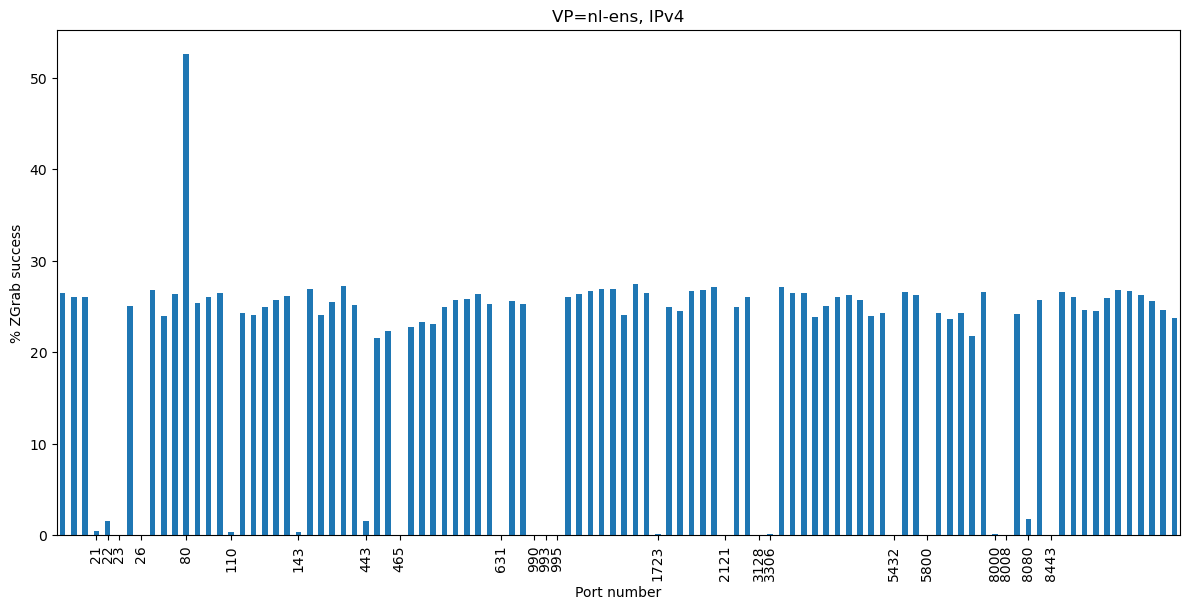

In [202]:
error_cdf_pdf = get_cdf_pdf_port_error_cnt(zgrab_v4_nl_service_df.filter(
        psf.col("service") == "Error"
    ).groupBy("port").count()
)

cdf_pdf = get_cdf_pdf_port_error_cnt(zgrab_v4_nl_service_df.filter(
        psf.col("service") != "Error"
    ).groupBy("port").count()
)
pct_pdf = get_success_pct_pdf(cdf_pdf, error_cdf_pdf)
#cdf_pdf.columns = ["port", "success_pct", "cdf_pct"]

plot_bargraph_ports(pct_pdf, 22, 1, "nl-ens", "IPv4")

In [80]:
# popular ports:
zmap_v4_nl_ts = datetime(2025, 12, 2)  # 2 and 3
vp = "nl-ens"
ZMAP_V4_NL_BASE_PATH = f"s3a://catrin/measurements/tool=zmap/dataset=tcp-anycast/vp={vp}"

zmap_v4_nl_df = spark.read.option("basePath", ZMAP_V4_NL_BASE_PATH).option("header", "true").csv(ZMAP_V4_NL_BASE_PATH).filter(psf.col("month") >= zmap_v4_nl_ts.month)
popular_ports = zmap_v4_nl_df.groupBy("port").count().sort("count", ascending=False).limit(5).select("port").toPandas()["port"].to_list()

print(popular_ports)

[443, 80, 8443, 8080, 53]


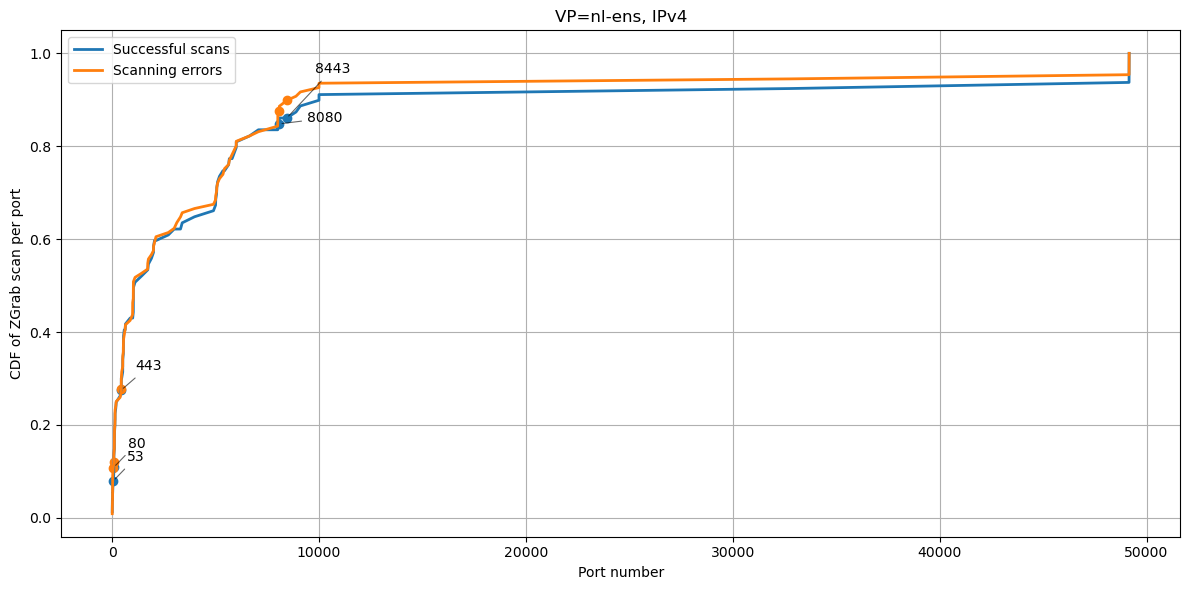

In [118]:
def plot_ports_cdf(pdf, error_pdf, highlight_ports, vp, version):    
    fig, ax = plt.subplots(figsize=(12, 6))

    # main CDF
    pdf.plot(
        ax=ax,
        x="port",
        y="cdf_pct",
        linewidth=2.0,
        label="Successful scans",
        legend=False,   # we'll add legend at the end
    )

    # error CDF on same plot
    error_pdf.plot(
        ax=ax,
        x="port",
        y="cdf_pct",
        linewidth=2.0,
        label="Scanning errors",
        legend=False,
    )
    
    plt.ylabel("CDF of ZGrab scan per port")
    plt.xlabel("Port number")

    # mark specific ports only
    hp = pdf[pdf["port"].isin(highlight_ports)]
    plt.scatter(hp.port, hp["cdf_pct"])
    ehp = error_pdf[error_pdf["port"].isin(highlight_ports)]
    plt.scatter(ehp.port, ehp["cdf_pct"])

    # label them on the curve
    if False:
        for _, row in hp.iterrows():
            x = row["port"]
            plt.annotate(
                str(int(row["port"])),
                (row.name, row["cdf_pct"]),
                textcoords="offset points",
                xytext=(12,12),
                ha="left", va="bottom",
                fontsize=10
            )
    # annotate: place label near the scatter point
    for i, (_, row) in enumerate(hp.iterrows()):
        x,y=(10,12)
        if row["port"] == 8443:
            x,y=(20,30)
        if row["port"] == 8080:
            x,y=(20,-1)
        
        ax.annotate(
            text=str(int(row["port"])),
            xy=(row["port"], row["cdf_pct"]),   # IMPORTANT: use port as x
            xytext=(x, y),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=10,
            #bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
            arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.6),
        )

    ax.legend()
    plt.title(f"VP={vp}, {version}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_cdf(cdf_pdf, error_cdf_pdf, popular_ports, "nl-ens", "IPv4")

#### HRP

In [158]:
zgrab_hrp_v4_nl_ts = datetime(2025, 12, 14)
vp = "nl-ens"

ZGRAB_HRP_V4_NL_BASE_PATH = f"s3a://catrin/measurements/tool=zgrab/dataset=tcp-anycast-hrp/format=parquet/vp={vp}/port=top100"

zgrab_hrp_v4_nl_df = spark.read.option("basePath", ZGRAB_HRP_V4_NL_BASE_PATH).parquet(ZGRAB_HRP_V4_NL_BASE_PATH)

#zgrab_hrp_v4_nl_df.show()

In [15]:
# protocols scanned:
protocols = zgrab_hrp_v4_nl_df.schema["data"].dataType.names
print(protocols)

['banner', 'ftp', 'ftps', 'http', 'https', 'imap', 'imaps', 'ipp', 'mysql', 'pop3', 'pop3s', 'postgres', 'pptp', 'smtps', 'ssh', 'telnet']


In [38]:
protocols = zgrab_hrp_v4_nl_df.schema["data"].dataType.names

for protocol in protocols:
    print(protocol)
    zgrab_hrp_v4_nl_df.filter(
        psf.col(f"data.{protocol}.status").isNotNull()
    ).groupBy(f"data.{protocol}.status").count().show()


banner
+------------------+-------+
|            status|  count|
+------------------+-------+
|           success|1393135|
|connection-timeout| 175060|
|        io-timeout|6269415|
|blocklisted-target|    100|
+------------------+-------+

ftp
+------------------+------+
|            status| count|
+------------------+------+
|           success|    39|
|connection-timeout|  7832|
|        io-timeout|295529|
+------------------+------+

ftps
+------------------+-----+
|            status|count|
+------------------+-----+
|connection-timeout| 2195|
|        io-timeout|64561|
|     unknown-error|34044|
+------------------+-----+

http
+------------------+------+
|            status| count|
+------------------+------+
|           success|857801|
|connection-timeout| 15814|
|        io-timeout|790361|
|     unknown-error|   624|
+------------------+------+

https
+------------------+-------+
|            status|  count|
+------------------+-------+
|           success|   7823|
|connection-

In [37]:
zgrab_hrp_v4_nl_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("service").count(
).show(truncate=False)

+----------+--------+
|service   |count   |
+----------+--------+
|NoResponse|10030269|
|https     |7823    |
|banner    |1393135 |
|smtps     |1       |
|imap      |7       |
|postgres  |22      |
|http      |857801  |
|pptp      |1       |
|ssh       |1597    |
|pop3      |6       |
|mysql     |9       |
|ftp       |39      |
+----------+--------+



In [12]:
zgrab_hrp_v4_nl_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    (psf.size("services") >= 1) &
    (psf.col("services") != psf.array(psf.lit("NoResponse")))
).select("ip").distinct().count()

622152

In [40]:
zgrab_hrp_v4_nl_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    ~(
        (psf.size("services") >= 1) &
        (psf.col("services") != psf.array(psf.lit("NoResponse")))
    )
).select("ip").distinct().count()

273263

In [3]:
622152/(622152+273263)*100

69.48197204648125

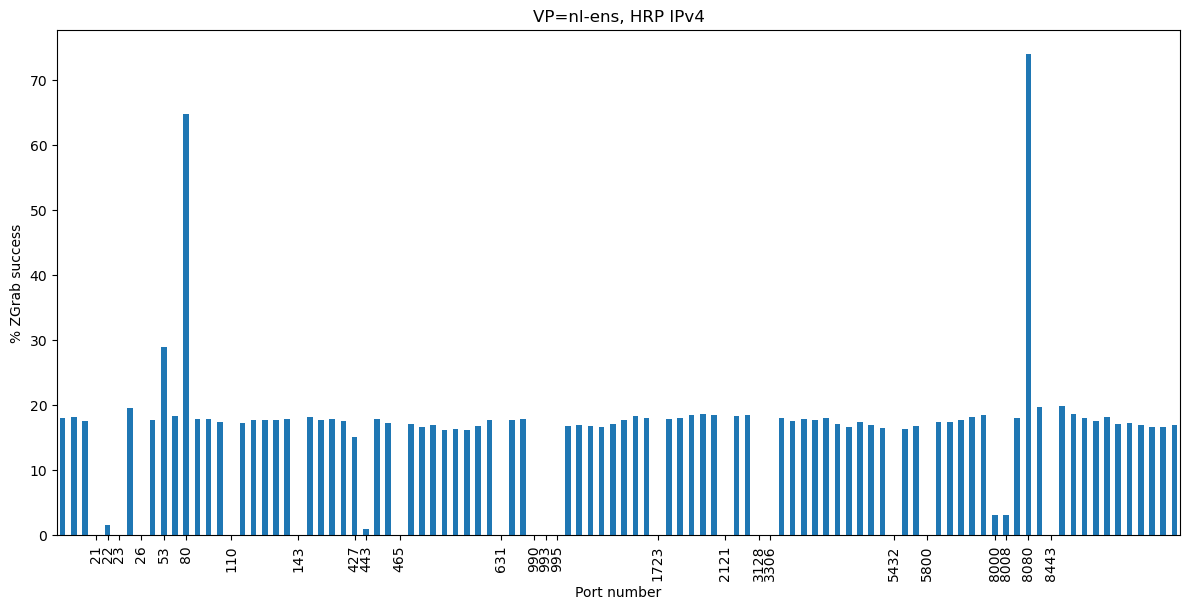

In [191]:
zgrab_hrp_v4_nl_service_df = get_df_service_from_zgrab_data(
    zgrab_hrp_v4_nl_df
).select("ip", "port", "service", "year", "month", "day")

error_cdf_pdf = get_cdf_pdf_port_error_cnt(zgrab_hrp_v4_nl_service_df.filter(
        psf.col("service") == "Error"
    ).groupBy("port").count()
)

cdf_pdf = get_cdf_pdf_port_error_cnt(zgrab_hrp_v4_nl_service_df.filter(
        psf.col("service") != "Error"
    ).groupBy("port").count()
)
pct_pdf = get_success_pct_pdf(cdf_pdf, error_cdf_pdf)

plot_bargraph_ports(pct_pdf, 22, 3, "nl-ens", "HRP IPv4")

### IPv4 AU -- old

#### no HRP

In [28]:
zgrab_v4_au_ts = datetime(2025, 12, 15)
vp = "au-syd"

ZGRAB_V4_AU_BASE_PATH = f"s3a://catrin/measurements/tool=zgrab/dataset=tcp-anycast/format=parquet/vp={vp}/port=top100"

zgrab_v4_au_df = spark.read.option("basePath", ZGRAB_V4_AU_BASE_PATH).parquet(ZGRAB_V4_AU_BASE_PATH)

In [29]:
zgrab_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("service").count(
).show(truncate=False)

+----------+--------+
|service   |count   |
+----------+--------+
|postgres  |158     |
|NoResponse|23305766|
|banner    |10879627|
|https     |3746    |
|http      |119099  |
|imaps     |110     |
|mysql     |292     |
|ftps      |6       |
|pop3s     |254     |
|smtps     |316     |
|telnet    |99      |
|ftp       |1758    |
|imap      |1149    |
|pop3      |1036    |
|pptp      |289     |
|ipp       |1       |
|ssh       |5923    |
+----------+--------+



In [30]:
zgrab_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    (psf.size("services") >= 1) &
    (psf.col("services") != psf.array(psf.lit("NoResponse")))
).select("ip").distinct().count()

410663

In [41]:
zgrab_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    ~(
        (psf.size("services") >= 1) &
        (psf.col("services") != psf.array(psf.lit("NoResponse")))
    )
).select("ip").distinct().count()

180635

In [4]:
410663/(410663+180635)*100

69.45110587216598

#### HRP

In [31]:
zgrab_hrp_v4_au_ts = datetime(2025, 12, 16)
vp = "au-syd"

ZGRAB_HRP_V4_AU_BASE_PATH = f"s3a://catrin/measurements/tool=zgrab/dataset=tcp-anycast-hrp/format=parquet/vp={vp}/port=top100"

zgrab_hrp_v4_au_df = spark.read.option("basePath", ZGRAB_HRP_V4_AU_BASE_PATH).parquet(ZGRAB_HRP_V4_AU_BASE_PATH)

#zgrab_hrp_v4_au_df.show()

In [32]:
zgrab_hrp_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("service").count(
).show(truncate=False)

+----------+--------+
|service   |count   |
+----------+--------+
|NoResponse|11877930|
|banner    |2105374 |
|https     |6856    |
|http      |774480  |
|postgres  |28      |
|pptp      |1       |
|ftp       |1336    |
|ssh       |1564    |
|imaps     |2       |
|imap      |1310    |
|mysql     |10      |
|smtps     |1       |
|pop3      |1307    |
|pop3s     |1       |
+----------+--------+



In [33]:
zgrab_hrp_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    (psf.size("services") >= 1) &
    (psf.col("services") != psf.array(psf.lit("NoResponse")))
).select("ip").distinct().count()

777751

In [42]:
zgrab_hrp_v4_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    ~(
        (psf.size("services") >= 1) &
        (psf.col("services") != psf.array(psf.lit("NoResponse")))
    )
).select("ip").distinct().count()

656670

In [6]:
777751/(777751+656670)*100

54.22055310121645

### IPv6 AU -- old

In [12]:
zgrab_v6_au_ts = datetime(2025, 12, 16)
vp = "au-syd"

ZGRAB_V6_AU_BASE_PATH = f"s3a://catrin/measurements/tool=zgrab/dataset=tcp-anycast-v6/format=parquet/vp={vp}"

zgrab_v6_au_df = spark.read.option("basePath", ZGRAB_V6_AU_BASE_PATH).parquet(ZGRAB_V6_AU_BASE_PATH).filter(psf.col("day") == psf.lit(zgrab_v6_au_ts.day))

zgrab_v6_au_df.show()

+--------------------+--------------------+------+----+-----+---+
|                data|                  ip|  port|year|month|day|
+--------------------+--------------------+------+----+-----+---+
|{{failed to conne...|2606:4700:3031::a...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3030::a...|top100|2025|   12| 16|
|{{failed to conne...|2001:8d8:fe:53:0:...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3031::a...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3035::6...|top100|2025|   12| 16|
|{{read tcp [2400:...|2606:4700:60:0:22...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3035::6...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3035::6...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3033::a...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3037::6...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3030::6...|top100|2025|   12| 16|
|{{failed to conne...|2606:4700:3035::a...|top100|2025|   12| 16|
|{{failed 

In [28]:
# protocols scanned:
protocols = zgrab_v6_au_df.schema["data"].dataType.names
print(protocols)

['banner', 'ftp', 'ftps', 'http', 'https', 'imap', 'imaps', 'ipp', 'mysql', 'pop3', 'pop3s', 'postgres', 'pptp', 'smtps', 'ssh', 'telnet']


In [27]:
protocols = zgrab_v6_au_df.schema["data"].dataType.names

for protocol in protocols:
    print(protocol)
    zgrab_v6_au_df.filter(
        psf.col(f"data.{protocol}.status").isNotNull()
    ).groupBy(f"data.{protocol}.status").count().show()

banner
+------------------+------+
|            status| count|
+------------------+------+
|           success|  2017|
|connection-timeout|446601|
|        io-timeout| 14614|
|blocklisted-target|    77|
+------------------+------+

ftp
+------------------+-----+
|            status|count|
+------------------+-----+
|connection-timeout|17231|
|        io-timeout|  817|
|blocklisted-target|    3|
+------------------+-----+

ftps
+------------------+-----+
|            status|count|
+------------------+-----+
|connection-timeout| 5625|
|        io-timeout|   31|
|     unknown-error|  360|
|blocklisted-target|    1|
+------------------+-----+

http
+------------------+-----+
|            status|count|
+------------------+-----+
|           success| 8956|
|connection-timeout|26531|
|        io-timeout|  609|
|blocklisted-target|    6|
+------------------+-----+

https
+------------------+-----+
|            status|count|
+------------------+-----+
|connection-timeout| 3578|
|        io-time

In [29]:
zgrab_v6_au_df.filter(
    psf.col("data.banner.status").isNotNull()
).filter(
    psf.col("data.banner.status") == "success"
).groupBy("ip").agg(psf.collect_set("data.banner.result.banner").alias("banner_set")
).groupBy("banner_set").count().sort("count", ascending=False).show(truncate=True)

+--------------------+-----+
|          banner_set|count|
+--------------------+-----+
|                  []| 1064|
|[HTTP/1.1 400 Bad...|    9|
|[����������������...|    3|
|[SSH-2.0-OpenSSH_...|    3|
|[@RSYNCD: 31.0\n@...|    2|
|[   �         ...|    1|
|           [ERROR\n]|    1|
+--------------------+-----+



In [23]:
zgrab_v6_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("service").count(
).show(truncate=False)

+----------+--------+
|service   |count   |
+----------+--------+
|postgres  |4       |
|NoResponse|15677000|
|http      |270951  |
|banner    |25932   |
|ftps      |1       |
|pop3      |7       |
|imap      |11      |
|ftp       |5       |
|mysql     |4       |
|https     |157     |
|telnet    |1       |
|ssh       |927     |
+----------+--------+



In [15]:
zgrab_v6_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).filter(
    ~(psf.col("service").isin(["NoResponse", "Unknown", "Error"])
).select("ip").distinct().count()

149621

In [24]:
zgrab_v6_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    (psf.size("services") >= 1) &
    (psf.col("services") != p(sf.array(psf.lit("NoResponse")))
).select("ip").distinct().count()

149621

In [43]:
zgrab_v6_au_df.withColumn(
    "service", get_service_from_zgrab_data(psf.col("data"))
).groupBy("ip").agg(psf.collect_set("service").alias("services"), psf.collect_set("port").alias("ports")
).filter(
    ~(
        (psf.size("services") >= 1) &
        (psf.col("services") != psf.array(psf.lit("NoResponse")))
    )
).select("ip").distinct().count()

10127

In [8]:
149621/(149621+10127)*100

93.66064050880136